In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import ScalarMappable

import seaborn as sns
from scipy.interpolate import griddata

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

import warnings
warnings.filterwarnings("ignore")

def q1(x):
    return x.quantile(0.25)

def q3(x):
    return x.quantile(0.75)

# Analysis for NHB submission

### reading the data

##### Global social norm calculation (all)

In [ ]:
# global (all) SN calculation
data_all_i = pd.read_csv('../results/model_data_exp_all_i.csv', header = [0])
data_all_ii = pd.read_csv('../results/model_data_exp_all_ii.csv', header = [0])
data_all_iii = pd.read_csv('../results/model_data_exp_all_iii.csv', header = [0])
data_all_iv = pd.read_csv('../results/model_data_exp_all_iv.csv', header = [0])
data_all_v = pd.read_csv('../results/model_data_exp_all_v.csv', header = [0])

data_all_i.head()

,Unnamed: 0,Step,seed,nr_households,set_hh_adapted_at_start,prop_inc_for_damage_adaptation,exchange_what,social_norm_calculation,per_HH_adapted_to_SN_prob_midpoint,weight_SN_vs_PMT,opinion_dynamics_model,weight_opinion_others,threshold_similarity_bias,flood_depth_in_m,flood_time,population_density,network_structure_file_path,proportion_ties_added_per_step,proportion_ties_removed_per_step,fraction_ties_added_at_flood,flood_remembrance_period,consider_measure_every_x_steps,minimum_intention_to_consider_measure,worry_increase_with_flood,min_worry_after_flood,damage_reduction,measures_aging,transformative_threshold,collect_agent_data,edges,avg_clustering,density_nw,cumulative_damage,cumulative_damage_no_adaptation,fraction_wet_proofed,fraction_dry_proofed,fraction_adapted_any,fraction_adapted_both,nr_HH_severely_affected,nr_HH_severely_affected_adapted_any,transformative_adaptation,avg_intention_SN,avg_intention_PMT_DP,avg_intention_PMT_WP,avg_intention_overall_DP,avg_intention_overall_WP
0,0,0,12345,1000,0.0,0.05,threat+coping,all,0.3,0.3,similarity_biased,0.5,0.2,"[99, 3, 1, 1, 1]",[15],"[[0, 50, 50, 50, 50], [0, 50, 50, 50, 50], [0,...",../data/processed/network_structures/network_e...,0,0,0,5,1,0,0.3,0.1,"{'dry-proofing': 0.5, 'wet-proofing': 0.4}","{'dry-proofing': 20, 'wet-proofing': 20}",0.7,0,393,0.00772,0.00079,16486146.0,16622680.0,0.022,0.006,0.022,0.006,250,5,0,0.0110,0.0109,0.0587,0.0109,0.0444
1,1,5,12345,1000,0.0,0.05,threat+coping,all,0.3,0.3,similarity_biased,0.5,0.2,"[99, 3, 1, 1, 1]",[15],"[[0, 50, 50, 50, 50], [0, 50, 50, 50, 50], [0,...",../data/processed/network_structures/network_e...,0,0,0,5,1,0,0.3,0.1,"{'dry-proofing': 0.5, 'wet-proofing': 0.4}","{'dry-proofing': 20, 'wet-proofing': 20}",0.7,0,393,0.00772,0.00079,16435578.0,16622680.0,0.030,0.026,0.030,0.026,250,7,0,0.0161,0.0322,0.0634,0.0274,0.0492
2,2,10,12345,1000,0.0,0.05,threat+coping,all,0.3,0.3,similarity_biased,0.5,0.2,"[99, 3, 1, 1, 1]",[15],"[[0, 50, 50, 50, 50], [0, 50, 50, 50, 50], [0,...",../data/processed/network_structures/network_e...,0,0,0,5,1,0,0.3,0.1,"{'dry-proofing': 0.5, 'wet-proofing': 0.4}","{'dry-proofing': 20, 'wet-proofing': 20}",0.7,0,393,0.00772,0.00079,16378542.0,16622680.0,0.040,0.027,0.040,0.027,250,9,0,0.0198,0.0431,0.0641,0.0361,0.0508
3,3,15,12345,1000,0.0,0.05,threat+coping,all,0.3,0.3,similarity_biased,0.5,0.2,"[99, 3, 1, 1, 1]",[15],"[[0, 50, 50, 50, 50], [0, 50, 50, 50, 50], [0,...",../data/processed/network_structures/network_e...,0,0,0,5,1,0,0.3,0.1,"{'dry-proofing': 0.5, 'wet-proofing': 0.4}","{'dry-proofing': 20, 'wet-proofing': 20}",0.7,0,393,0.00772,0.00079,16214136.0,16622680.0,0.061,0.031,0.061,0.031,250,15,0,0.0198,0.0450,0.1010,0.0374,0.0766
4,4,20,12345,1000,0.0,0.05,threat+coping,all,0.3,0.3,similarity_biased,0.5,0.2,"[99, 3, 1, 1, 1]",[15],"[[0, 50, 50, 50, 50], [0, 50, 50, 50, 50], [0,...",../data/processed/network_structures/network_e...,0,0,0,5,1,0,0.3,0.1,"{'dry-proofing': 0.5, 'wet-proofing': 0.4}","{'dry-proofing': 20, 'wet-proofing': 20}",0.7,0,393,0.00772,0.00079,16205381.0,16622680.0,0.063,0.035,0.063,0.035,250,15,0,0.0251,0.0440,0.0989,0.0383,0.0768


In [3]:
data_all_i.shape

(330330, 46)

In [4]:
data_all = [data_all_i, data_all_ii, data_all_iii, data_all_iv, data_all_v]
data_all = pd.concat(data_all)
data_all.shape

data_all = data_all.drop(columns = ['Unnamed: 0'])
data_all.head()

,Step,seed,nr_households,set_hh_adapted_at_start,prop_inc_for_damage_adaptation,exchange_what,social_norm_calculation,per_HH_adapted_to_SN_prob_midpoint,weight_SN_vs_PMT,opinion_dynamics_model,weight_opinion_others,threshold_similarity_bias,flood_depth_in_m,flood_time,population_density,network_structure_file_path,proportion_ties_added_per_step,proportion_ties_removed_per_step,fraction_ties_added_at_flood,flood_remembrance_period,consider_measure_every_x_steps,minimum_intention_to_consider_measure,worry_increase_with_flood,min_worry_after_flood,damage_reduction,measures_aging,transformative_threshold,collect_agent_data,edges,avg_clustering,density_nw,cumulative_damage,cumulative_damage_no_adaptation,fraction_wet_proofed,fraction_dry_proofed,fraction_adapted_any,fraction_adapted_both,nr_HH_severely_affected,nr_HH_severely_affected_adapted_any,transformative_adaptation,avg_intention_SN,avg_intention_PMT_DP,avg_intention_PMT_WP,avg_intention_overall_DP,avg_intention_overall_WP
0,0,12345,1000,0.0,0.05,threat+coping,all,0.3,0.3,similarity_biased,0.5,0.2,"[99, 3, 1, 1, 1]",[15],"[[0, 50, 50, 50, 50], [0, 50, 50, 50, 50], [0,...",../data/processed/network_structures/network_e...,0,0,0,5,1,0,0.3,0.1,"{'dry-proofing': 0.5, 'wet-proofing': 0.4}","{'dry-proofing': 20, 'wet-proofing': 20}",0.7,0,393,0.00772,0.00079,16486146.0,16622680.0,0.022,0.006,0.022,0.006,250,5,0,0.0110,0.0109,0.0587,0.0109,0.0444
1,5,12345,1000,0.0,0.05,threat+coping,all,0.3,0.3,similarity_biased,0.5,0.2,"[99, 3, 1, 1, 1]",[15],"[[0, 50, 50, 50, 50], [0, 50, 50, 50, 50], [0,...",../data/processed/network_structures/network_e...,0,0,0,5,1,0,0.3,0.1,"{'dry-proofing': 0.5, 'wet-proofing': 0.4}","{'dry-proofing': 20, 'wet-proofing': 20}",0.7,0,393,0.00772,0.00079,16435578.0,16622680.0,0.030,0.026,0.030,0.026,250,7,0,0.0161,0.0322,0.0634,0.0274,0.0492
2,10,12345,1000,0.0,0.05,threat+coping,all,0.3,0.3,similarity_biased,0.5,0.2,"[99, 3, 1, 1, 1]",[15],"[[0, 50, 50, 50, 50], [0, 50, 50, 50, 50], [0,...",../data/processed/network_structures/network_e...,0,0,0,5,1,0,0.3,0.1,"{'dry-proofing': 0.5, 'wet-proofing': 0.4}","{'dry-proofing': 20, 'wet-proofing': 20}",0.7,0,393,0.00772,0.00079,16378542.0,16622680.0,0.040,0.027,0.040,0.027,250,9,0,0.0198,0.0431,0.0641,0.0361,0.0508
3,15,12345,1000,0.0,0.05,threat+coping,all,0.3,0.3,similarity_biased,0.5,0.2,"[99, 3, 1, 1, 1]",[15],"[[0, 50, 50, 50, 50], [0, 50, 50, 50, 50], [0,...",../data/processed/network_structures/network_e...,0,0,0,5,1,0,0.3,0.1,"{'dry-proofing': 0.5, 'wet-proofing': 0.4}","{'dry-proofing': 20, 'wet-proofing': 20}",0.7,0,393,0.00772,0.00079,16214136.0,16622680.0,0.061,0.031,0.061,0.031,250,15,0,0.0198,0.0450,0.1010,0.0374,0.0766
4,20,12345,1000,0.0,0.05,threat+coping,all,0.3,0.3,similarity_biased,0.5,0.2,"[99, 3, 1, 1, 1]",[15],"[[0, 50, 50, 50, 50], [0, 50, 50, 50, 50], [0,...",../data/processed/network_structures/network_e...,0,0,0,5,1,0,0.3,0.1,"{'dry-proofing': 0.5, 'wet-proofing': 0.4}","{'dry-proofing': 20, 'wet-proofing': 20}",0.7,0,393,0.00772,0.00079,16205381.0,16622680.0,0.063,0.035,0.063,0.035,250,15,0,0.0251,0.0440,0.0989,0.0383,0.0768


In [5]:
data_all[["per_HH_adapted_to_SN_prob_midpoint", "weight_SN_vs_PMT"]] = data_all[["per_HH_adapted_to_SN_prob_midpoint", "weight_SN_vs_PMT"]].apply(pd.to_numeric)
data_all = data_all.round({'per_HH_adapted_to_SN_prob_midpoint': 2, 'weight_SN_vs_PMT': 2})

In [6]:
data_all.shape

(1651650, 45)

##### Local social norm calculation (district)

In [ ]:
# global (all) SN calculation
data_district_i = pd.read_csv('../results/model_data_exp_district_i.csv', header = [0])
data_district_ii = pd.read_csv('../results/model_data_exp_district_ii.csv', header = [0])
data_district_iii = pd.read_csv('../results/model_data_exp_district_iii.csv', header = [0])
data_district_iv = pd.read_csv('../results/model_data_exp_district_iv.csv', header = [0])
data_district_v = pd.read_csv('../results/model_data_exp_district_v.csv', header = [0])

data_district_i.head()

,Unnamed: 0,Step,seed,nr_households,set_hh_adapted_at_start,prop_inc_for_damage_adaptation,exchange_what,social_norm_calculation,per_HH_adapted_to_SN_prob_midpoint,weight_SN_vs_PMT,opinion_dynamics_model,weight_opinion_others,threshold_similarity_bias,flood_depth_in_m,flood_time,population_density,network_structure_file_path,proportion_ties_added_per_step,proportion_ties_removed_per_step,fraction_ties_added_at_flood,flood_remembrance_period,consider_measure_every_x_steps,minimum_intention_to_consider_measure,worry_increase_with_flood,min_worry_after_flood,damage_reduction,measures_aging,transformative_threshold,collect_agent_data,edges,avg_clustering,density_nw,cumulative_damage,cumulative_damage_no_adaptation,fraction_wet_proofed,fraction_dry_proofed,fraction_adapted_any,fraction_adapted_both,nr_HH_severely_affected,nr_HH_severely_affected_adapted_any,transformative_adaptation,avg_intention_SN,avg_intention_PMT_DP,avg_intention_PMT_WP,avg_intention_overall_DP,avg_intention_overall_WP
0,0,0,12345,1000,0.0,0.05,threat+coping,district,0.3,0.55,similarity_biased,0.5,0.2,"[99, 3, 1, 1, 1]",[15],"[[0, 50, 50, 50, 50], [0, 50, 50, 50, 50], [0,...",../data/processed/network_structures/network_e...,0,0,0,5,1,0,0.3,0.1,"{'dry-proofing': 0.5, 'wet-proofing': 0.4}","{'dry-proofing': 20, 'wet-proofing': 20}",0.7,0,393,0.00772,0.00079,16491203.0,16622680.0,0.021,0.006,0.021,0.006,250,5,0,0.0131,0.0109,0.0587,0.0121,0.0336
1,1,5,12345,1000,0.0,0.05,threat+coping,district,0.3,0.55,similarity_biased,0.5,0.2,"[99, 3, 1, 1, 1]",[15],"[[0, 50, 50, 50, 50], [0, 50, 50, 50, 50], [0,...",../data/processed/network_structures/network_e...,0,0,0,5,1,0,0.3,0.1,"{'dry-proofing': 0.5, 'wet-proofing': 0.4}","{'dry-proofing': 20, 'wet-proofing': 20}",0.7,0,393,0.00772,0.00079,16445692.0,16622680.0,0.028,0.024,0.028,0.024,250,7,0,0.0169,0.0306,0.0629,0.0230,0.0376
2,2,10,12345,1000,0.0,0.05,threat+coping,district,0.3,0.55,similarity_biased,0.5,0.2,"[99, 3, 1, 1, 1]",[15],"[[0, 50, 50, 50, 50], [0, 50, 50, 50, 50], [0,...",../data/processed/network_structures/network_e...,0,0,0,5,1,0,0.3,0.1,"{'dry-proofing': 0.5, 'wet-proofing': 0.4}","{'dry-proofing': 20, 'wet-proofing': 20}",0.7,0,393,0.00772,0.00079,16418997.0,16622680.0,0.033,0.024,0.033,0.024,250,8,0,0.0189,0.0377,0.0633,0.0274,0.0389
3,3,15,12345,1000,0.0,0.05,threat+coping,district,0.3,0.55,similarity_biased,0.5,0.2,"[99, 3, 1, 1, 1]",[15],"[[0, 50, 50, 50, 50], [0, 50, 50, 50, 50], [0,...",../data/processed/network_structures/network_e...,0,0,0,5,1,0,0.3,0.1,"{'dry-proofing': 0.5, 'wet-proofing': 0.4}","{'dry-proofing': 20, 'wet-proofing': 20}",0.7,0,393,0.00772,0.00079,16315273.0,16622680.0,0.044,0.028,0.044,0.028,250,12,0,0.0212,0.0394,0.1003,0.0294,0.0568
4,4,20,12345,1000,0.0,0.05,threat+coping,district,0.3,0.55,similarity_biased,0.5,0.2,"[99, 3, 1, 1, 1]",[15],"[[0, 50, 50, 50, 50], [0, 50, 50, 50, 50], [0,...",../data/processed/network_structures/network_e...,0,0,0,5,1,0,0.3,0.1,"{'dry-proofing': 0.5, 'wet-proofing': 0.4}","{'dry-proofing': 20, 'wet-proofing': 20}",0.7,0,393,0.00772,0.00079,16281233.0,16622680.0,0.051,0.025,0.051,0.025,250,12,0,0.0250,0.0342,0.0964,0.0291,0.0571


In [8]:
data_district_i.shape

(330330, 46)

In [9]:
data_district = [data_district_i, data_district_ii, data_district_iii, data_district_iv, data_district_v]
data_district = pd.concat(data_district)
data_district.shape

data_district = data_district.drop(columns = ['Unnamed: 0'])
data_district.head()

,Step,seed,nr_households,set_hh_adapted_at_start,prop_inc_for_damage_adaptation,exchange_what,social_norm_calculation,per_HH_adapted_to_SN_prob_midpoint,weight_SN_vs_PMT,opinion_dynamics_model,weight_opinion_others,threshold_similarity_bias,flood_depth_in_m,flood_time,population_density,network_structure_file_path,proportion_ties_added_per_step,proportion_ties_removed_per_step,fraction_ties_added_at_flood,flood_remembrance_period,consider_measure_every_x_steps,minimum_intention_to_consider_measure,worry_increase_with_flood,min_worry_after_flood,damage_reduction,measures_aging,transformative_threshold,collect_agent_data,edges,avg_clustering,density_nw,cumulative_damage,cumulative_damage_no_adaptation,fraction_wet_proofed,fraction_dry_proofed,fraction_adapted_any,fraction_adapted_both,nr_HH_severely_affected,nr_HH_severely_affected_adapted_any,transformative_adaptation,avg_intention_SN,avg_intention_PMT_DP,avg_intention_PMT_WP,avg_intention_overall_DP,avg_intention_overall_WP
0,0,12345,1000,0.0,0.05,threat+coping,district,0.3,0.55,similarity_biased,0.5,0.2,"[99, 3, 1, 1, 1]",[15],"[[0, 50, 50, 50, 50], [0, 50, 50, 50, 50], [0,...",../data/processed/network_structures/network_e...,0,0,0,5,1,0,0.3,0.1,"{'dry-proofing': 0.5, 'wet-proofing': 0.4}","{'dry-proofing': 20, 'wet-proofing': 20}",0.7,0,393,0.00772,0.00079,16491203.0,16622680.0,0.021,0.006,0.021,0.006,250,5,0,0.0131,0.0109,0.0587,0.0121,0.0336
1,5,12345,1000,0.0,0.05,threat+coping,district,0.3,0.55,similarity_biased,0.5,0.2,"[99, 3, 1, 1, 1]",[15],"[[0, 50, 50, 50, 50], [0, 50, 50, 50, 50], [0,...",../data/processed/network_structures/network_e...,0,0,0,5,1,0,0.3,0.1,"{'dry-proofing': 0.5, 'wet-proofing': 0.4}","{'dry-proofing': 20, 'wet-proofing': 20}",0.7,0,393,0.00772,0.00079,16445692.0,16622680.0,0.028,0.024,0.028,0.024,250,7,0,0.0169,0.0306,0.0629,0.0230,0.0376
2,10,12345,1000,0.0,0.05,threat+coping,district,0.3,0.55,similarity_biased,0.5,0.2,"[99, 3, 1, 1, 1]",[15],"[[0, 50, 50, 50, 50], [0, 50, 50, 50, 50], [0,...",../data/processed/network_structures/network_e...,0,0,0,5,1,0,0.3,0.1,"{'dry-proofing': 0.5, 'wet-proofing': 0.4}","{'dry-proofing': 20, 'wet-proofing': 20}",0.7,0,393,0.00772,0.00079,16418997.0,16622680.0,0.033,0.024,0.033,0.024,250,8,0,0.0189,0.0377,0.0633,0.0274,0.0389
3,15,12345,1000,0.0,0.05,threat+coping,district,0.3,0.55,similarity_biased,0.5,0.2,"[99, 3, 1, 1, 1]",[15],"[[0, 50, 50, 50, 50], [0, 50, 50, 50, 50], [0,...",../data/processed/network_structures/network_e...,0,0,0,5,1,0,0.3,0.1,"{'dry-proofing': 0.5, 'wet-proofing': 0.4}","{'dry-proofing': 20, 'wet-proofing': 20}",0.7,0,393,0.00772,0.00079,16315273.0,16622680.0,0.044,0.028,0.044,0.028,250,12,0,0.0212,0.0394,0.1003,0.0294,0.0568
4,20,12345,1000,0.0,0.05,threat+coping,district,0.3,0.55,similarity_biased,0.5,0.2,"[99, 3, 1, 1, 1]",[15],"[[0, 50, 50, 50, 50], [0, 50, 50, 50, 50], [0,...",../data/processed/network_structures/network_e...,0,0,0,5,1,0,0.3,0.1,"{'dry-proofing': 0.5, 'wet-proofing': 0.4}","{'dry-proofing': 20, 'wet-proofing': 20}",0.7,0,393,0.00772,0.00079,16281233.0,16622680.0,0.051,0.025,0.051,0.025,250,12,0,0.0250,0.0342,0.0964,0.0291,0.0571


In [10]:
data_district[["per_HH_adapted_to_SN_prob_midpoint", "weight_SN_vs_PMT"]] = data_district[["per_HH_adapted_to_SN_prob_midpoint", "weight_SN_vs_PMT"]].apply(pd.to_numeric)
data_district = data_district.round({'per_HH_adapted_to_SN_prob_midpoint': 2, 'weight_SN_vs_PMT': 2})

In [11]:
data_district.shape

(1651650, 45)

###### Within district tipping

In [ ]:
data_district_tipping_i = pd.read_csv('../results/model_data_exp_district_tipping_1.csv', header = [0])
data_district_tipping_ii = pd.read_csv('../results/model_data_exp_district_tipping_2.csv', header = [0])
data_district_tipping_iii = pd.read_csv('../results/model_data_exp_district_tipping_3.csv', header = [0])
data_district_tipping_iv = pd.read_csv('../results/model_data_exp_district_tipping_4.csv', header = [0])
data_district_tipping_v = pd.read_csv('../results/model_data_exp_district_tipping_5.csv', header = [0])

data_district_tipping = [data_district_tipping_i, data_district_tipping_ii, data_district_tipping_iii, data_district_tipping_iv, data_district_tipping_v]
data_district_tipping = pd.concat(data_district_tipping)
print(data_district_tipping.shape)

data_district_tipping = data_district_tipping.drop(columns = ['Unnamed: 0'])
data_district_tipping.head()

(1397550, 58)


,Step,seed,nr_households,set_hh_adapted_at_start,prop_inc_for_damage_adaptation,exchange_what,social_norm_calculation,per_HH_adapted_to_SN_prob_midpoint,weight_SN_vs_PMT,opinion_dynamics_model,weight_opinion_others,threshold_similarity_bias,flood_depth_in_m,flood_time,population_density,network_structure_file_path,proportion_ties_added_per_step,proportion_ties_removed_per_step,fraction_ties_added_at_flood,flood_remembrance_period,consider_measure_every_x_steps,minimum_intention_to_consider_measure,worry_increase_with_flood,min_worry_after_flood,damage_reduction,measures_aging,transformative_threshold,collect_agent_data,edges,avg_clustering,density_nw,cumulative_damage,cumulative_damage_no_adaptation,fraction_wet_proofed,fraction_dry_proofed,fraction_adapted_any,fraction_adapted_both,adapted_wp_11,adapted_dp_11,adapted_any_11,adapted_both_11,adapted_wp_21,adapted_dp_21,adapted_any_21,adapted_both_21,adapted_wp_12,adapted_dp_12,adapted_any_12,adapted_both_12,nr_HH_severely_affected,nr_HH_severely_affected_adapted_any,transformative_adaptation,avg_intention_SN,avg_intention_PMT_DP,avg_intention_PMT_WP,avg_intention_overall_DP,avg_intention_overall_WP
0,0,12345,1000,0.0,0.05,threat+coping,district,0.3,0.3,similarity_biased,0.5,0.2,"[99, 3, 1, 1, 1]",[15],"[[0, 50, 50, 50, 50], [0, 50, 50, 50, 50], [0,...",../data/processed/network_structures/network_e...,0,0,0,5,1,0,0.3,0.1,"{'dry-proofing': 0.5, 'wet-proofing': 0.4}","{'dry-proofing': 20, 'wet-proofing': 20}",0.8,0,393,0.00772,0.00079,16486146.0,16622680.0,0.022,0.006,0.022,0.006,0,0,0,0,2,0,2,0,1,0,1,0,250,5,0,0.0132,0.0109,0.0587,0.0116,0.0451
1,5,12345,1000,0.0,0.05,threat+coping,district,0.3,0.3,similarity_biased,0.5,0.2,"[99, 3, 1, 1, 1]",[15],"[[0, 50, 50, 50, 50], [0, 50, 50, 50, 50], [0,...",../data/processed/network_structures/network_e...,0,0,0,5,1,0,0.3,0.1,"{'dry-proofing': 0.5, 'wet-proofing': 0.4}","{'dry-proofing': 20, 'wet-proofing': 20}",0.8,0,393,0.00772,0.00079,16430521.0,16622680.0,0.031,0.027,0.031,0.027,1,0,1,0,3,2,3,2,3,2,3,2,250,7,0,0.0179,0.0330,0.0634,0.0284,0.0497
2,10,12345,1000,0.0,0.05,threat+coping,district,0.3,0.3,similarity_biased,0.5,0.2,"[99, 3, 1, 1, 1]",[15],"[[0, 50, 50, 50, 50], [0, 50, 50, 50, 50], [0,...",../data/processed/network_structures/network_e...,0,0,0,5,1,0,0.3,0.1,"{'dry-proofing': 0.5, 'wet-proofing': 0.4}","{'dry-proofing': 20, 'wet-proofing': 20}",0.8,0,393,0.00772,0.00079,16364730.0,16622680.0,0.043,0.028,0.043,0.028,2,0,2,0,3,2,3,2,4,2,4,2,250,9,0,0.0233,0.0454,0.0639,0.0388,0.0518
3,15,12345,1000,0.0,0.05,threat+coping,district,0.3,0.3,similarity_biased,0.5,0.2,"[99, 3, 1, 1, 1]",[15],"[[0, 50, 50, 50, 50], [0, 50, 50, 50, 50], [0,...",../data/processed/network_structures/network_e...,0,0,0,5,1,0,0.3,0.1,"{'dry-proofing': 0.5, 'wet-proofing': 0.4}","{'dry-proofing': 20, 'wet-proofing': 20}",0.8,0,393,0.00772,0.00079,16200324.0,16622680.0,0.064,0.032,0.064,0.032,3,1,3,1,5,3,5,3,6,3,6,3,250,15,0,0.0276,0.0474,0.1011,0.0415,0.0791
4,20,12345,1000,0.0,0.05,threat+coping,district,0.3,0.3,similarity_biased,0.5,0.2,"[99, 3, 1, 1, 1]",[15],"[[0, 50, 50, 50, 50], [0, 50, 50, 50, 50], [0,...",../data/processed/network_structures/network_e...,0,0,0,5,1,0,0.3,0.1,"{'dry-proofing': 0.5, 'wet-proofing': 0.4}","{'dry-proofing': 20, 'wet-proofing': 20}",0.8,0,393,0.00772,0.00079,16200324.0,16622680.0,0.064,0.036,0.064,0.036,3,2,3,2,5,3,5,3,6,4,6,4,250,15,0,0.0302,0.0455,0.0990,0.0409,0.0784


##### Empirical setup

In [ ]:
data_empirical = pd.read_csv('../results/model_data_empirical.csv', header = [0])
data_empirical = data_empirical.drop(columns = ['Unnamed: 0'])
data_empirical.head()

,Step,seed,nr_households,set_hh_adapted_at_start,prop_inc_for_damage_adaptation,exchange_what,social_norm_calculation,per_HH_adapted_to_SN_prob_midpoint,weight_SN_vs_PMT,opinion_dynamics_model,weight_opinion_others,threshold_similarity_bias,flood_depth_in_m,flood_time,population_density,network_structure_file_path,proportion_ties_added_per_step,proportion_ties_removed_per_step,fraction_ties_added_at_flood,flood_remembrance_period,consider_measure_every_x_steps,minimum_intention_to_consider_measure,worry_increase_with_flood,min_worry_after_flood,damage_reduction,measures_aging,transformative_threshold,collect_agent_data,edges,avg_clustering,density_nw,cumulative_damage,cumulative_damage_no_adaptation,fraction_wet_proofed,fraction_dry_proofed,fraction_adapted_any,fraction_adapted_both,nr_HH_severely_affected,nr_HH_severely_affected_adapted_any,transformative_adaptation,avg_intention_SN,avg_intention_PMT_DP,avg_intention_PMT_WP,avg_intention_overall_DP,avg_intention_overall_WP
0,0,12346,1000,False,0.05,threat+coping,district,uniform,empirical,similarity_biased,0.5,0.2,"[99, 3, 1, 1, 1]",[15],"[[0, 50, 50, 50, 50], [0, 50, 50, 50, 50], [0,...",../data/processed/network_structures/network_e...,0,0,0,5,1,0,0.3,0.1,"{'dry-proofing': 0.5, 'wet-proofing': 0.4}","{'dry-proofing': 20, 'wet-proofing': 20}",0.7,0,393,0.00772,0.00079,12412517.0,13099000.0,0.097,0.072,0.121,0.048,250,34,0,0.0112,0.0813,0.0700,0.0520,0.0428
1,1,12346,1000,False,0.05,threat+coping,district,uniform,empirical,similarity_biased,0.5,0.2,"[99, 3, 1, 1, 1]",[15],"[[0, 50, 50, 50, 50], [0, 50, 50, 50, 50], [0,...",../data/processed/network_structures/network_e...,0,0,0,5,1,0,0.3,0.1,"{'dry-proofing': 0.5, 'wet-proofing': 0.4}","{'dry-proofing': 20, 'wet-proofing': 20}",0.7,0,393,0.00772,0.00079,12461906.0,13099000.0,0.091,0.084,0.117,0.058,250,32,0,0.0111,0.0914,0.0769,0.0581,0.0477
2,2,12346,1000,False,0.05,threat+coping,district,uniform,empirical,similarity_biased,0.5,0.2,"[99, 3, 1, 1, 1]",[15],"[[0, 50, 50, 50, 50], [0, 50, 50, 50, 50], [0,...",../data/processed/network_structures/network_e...,0,0,0,5,1,0,0.3,0.1,"{'dry-proofing': 0.5, 'wet-proofing': 0.4}","{'dry-proofing': 20, 'wet-proofing': 20}",0.7,0,393,0.00772,0.00079,12457245.0,13099000.0,0.090,0.082,0.117,0.055,250,32,0,0.0107,0.0864,0.0791,0.0556,0.0486
3,3,12346,1000,False,0.05,threat+coping,district,uniform,empirical,similarity_biased,0.5,0.2,"[99, 3, 1, 1, 1]",[15],"[[0, 50, 50, 50, 50], [0, 50, 50, 50, 50], [0,...",../data/processed/network_structures/network_e...,0,0,0,5,1,0,0.3,0.1,"{'dry-proofing': 0.5, 'wet-proofing': 0.4}","{'dry-proofing': 20, 'wet-proofing': 20}",0.7,0,393,0.00772,0.00079,12496869.0,13099000.0,0.087,0.080,0.113,0.054,250,30,0,0.0103,0.0854,0.0784,0.0547,0.0479
4,4,12346,1000,False,0.05,threat+coping,district,uniform,empirical,similarity_biased,0.5,0.2,"[99, 3, 1, 1, 1]",[15],"[[0, 50, 50, 50, 50], [0, 50, 50, 50, 50], [0,...",../data/processed/network_structures/network_e...,0,0,0,5,1,0,0.3,0.1,"{'dry-proofing': 0.5, 'wet-proofing': 0.4}","{'dry-proofing': 20, 'wet-proofing': 20}",0.7,0,393,0.00772,0.00079,12509775.0,13099000.0,0.089,0.077,0.111,0.055,250,29,0,0.0100,0.0829,0.0780,0.0528,0.0476


In [ ]:
data_empirical_pot = pd.read_csv('../results/model_data_empirical_potential.csv', header = [0])
data_empirical_pot = data_empirical_pot.drop(columns = ['Unnamed: 0'])
data_empirical_pot.head()

,Step,seed,nr_households,set_hh_adapted_at_start,prop_inc_for_damage_adaptation,exchange_what,social_norm_calculation,per_HH_adapted_to_SN_prob_midpoint,weight_SN_vs_PMT,opinion_dynamics_model,weight_opinion_others,threshold_similarity_bias,flood_depth_in_m,flood_time,population_density,network_structure_file_path,proportion_ties_added_per_step,proportion_ties_removed_per_step,fraction_ties_added_at_flood,flood_remembrance_period,consider_measure_every_x_steps,minimum_intention_to_consider_measure,worry_increase_with_flood,min_worry_after_flood,damage_reduction,measures_aging,transformative_threshold,collect_agent_data,edges,avg_clustering,density_nw,cumulative_damage,cumulative_damage_no_adaptation,fraction_wet_proofed,fraction_dry_proofed,fraction_adapted_any,fraction_adapted_both,nr_HH_severely_affected,nr_HH_severely_affected_adapted_any,transformative_adaptation,avg_intention_SN,avg_intention_PMT_DP,avg_intention_PMT_WP,avg_intention_overall_DP,avg_intention_overall_WP
0,0,12345,1000,False,0.05,threat+coping,district,0.3,0.8,similarity_biased,0.5,0.2,"[99, 3, 1, 1, 1]",[15],"[[0, 50, 50, 50, 50], [0, 50, 50, 50, 50], [0,...",../data/processed/network_structures/network_e...,0,0,0,5,1,0,0.3,0.1,"{'dry-proofing': 0.5, 'wet-proofing': 0.4}","{'dry-proofing': 20, 'wet-proofing': 20}",0.7,0,393,0.00772,0.00079,15405069.0,16622680.0,0.141,0.115,0.164,0.092,250,53,0,0.1169,0.0804,0.0699,0.1096,0.1075
1,1,12345,1000,False,0.05,threat+coping,district,0.3,0.8,similarity_biased,0.5,0.2,"[99, 3, 1, 1, 1]",[15],"[[0, 50, 50, 50, 50], [0, 50, 50, 50, 50], [0,...",../data/processed/network_structures/network_e...,0,0,0,5,1,0,0.3,0.1,"{'dry-proofing': 0.5, 'wet-proofing': 0.4}","{'dry-proofing': 20, 'wet-proofing': 20}",0.7,0,393,0.00772,0.00079,14897498.0,16622680.0,0.211,0.190,0.235,0.166,250,75,0,0.2545,0.1254,0.0822,0.2287,0.2200
2,2,12345,1000,False,0.05,threat+coping,district,0.3,0.8,similarity_biased,0.5,0.2,"[99, 3, 1, 1, 1]",[15],"[[0, 50, 50, 50, 50], [0, 50, 50, 50, 50], [0,...",../data/processed/network_structures/network_e...,0,0,0,5,1,0,0.3,0.1,"{'dry-proofing': 0.5, 'wet-proofing': 0.4}","{'dry-proofing': 20, 'wet-proofing': 20}",0.7,0,393,0.00772,0.00079,14729368.0,16622680.0,0.232,0.216,0.255,0.193,250,89,0,0.3061,0.1795,0.0932,0.2808,0.2635
3,3,12345,1000,False,0.05,threat+coping,district,0.3,0.8,similarity_biased,0.5,0.2,"[99, 3, 1, 1, 1]",[15],"[[0, 50, 50, 50, 50], [0, 50, 50, 50, 50], [0,...",../data/processed/network_structures/network_e...,0,0,0,5,1,0,0.3,0.1,"{'dry-proofing': 0.5, 'wet-proofing': 0.4}","{'dry-proofing': 20, 'wet-proofing': 20}",0.7,0,393,0.00772,0.00079,14707874.0,16622680.0,0.241,0.218,0.261,0.198,250,88,0,0.3068,0.1964,0.0973,0.2847,0.2649
4,4,12345,1000,False,0.05,threat+coping,district,0.3,0.8,similarity_biased,0.5,0.2,"[99, 3, 1, 1, 1]",[15],"[[0, 50, 50, 50, 50], [0, 50, 50, 50, 50], [0,...",../data/processed/network_structures/network_e...,0,0,0,5,1,0,0.3,0.1,"{'dry-proofing': 0.5, 'wet-proofing': 0.4}","{'dry-proofing': 20, 'wet-proofing': 20}",0.7,0,393,0.00772,0.00079,14719252.0,16622680.0,0.240,0.219,0.259,0.200,250,88,0,0.3051,0.2034,0.0974,0.2848,0.2636


## Transformational Adaptation - under what circumstances
3d plot midpoint social norm curve, fraction adapted at start, weight SN vs PMT --> fraction adapted at end

each for global calculation of social norm (all) and local (district-based) calculation

In [15]:
data_all_last_step = data_all[data_all['Step'] == 50]
data_district_last_step = data_district[data_district['Step'] == 50]

In [16]:
data_all_last_step.columns

Index(['Step', 'seed', 'nr_households', 'set_hh_adapted_at_start',
       'prop_inc_for_damage_adaptation', 'exchange_what',
       'social_norm_calculation', 'per_HH_adapted_to_SN_prob_midpoint',
       'weight_SN_vs_PMT', 'opinion_dynamics_model', 'weight_opinion_others',
       'threshold_similarity_bias', 'flood_depth_in_m', 'flood_time',
       'population_density', 'network_structure_file_path',
       'proportion_ties_added_per_step', 'proportion_ties_removed_per_step',
       'fraction_ties_added_at_flood', 'flood_remembrance_period',
       'consider_measure_every_x_steps',
       'minimum_intention_to_consider_measure', 'worry_increase_with_flood',
       'min_worry_after_flood', 'damage_reduction', 'measures_aging',
       'transformative_threshold', 'collect_agent_data', 'edges',
       'avg_clustering', 'density_nw', 'cumulative_damage',
       'cumulative_damage_no_adaptation', 'fraction_wet_proofed',
       'fraction_dry_proofed', 'fraction_adapted_any', 'fraction_adapte

In [17]:
data_all_last_step_vis = data_all_last_step.drop(columns = ['Step', 'seed', 'nr_households', 
       'prop_inc_for_damage_adaptation', 'exchange_what', 'social_norm_calculation',
       'opinion_dynamics_model', 'weight_opinion_others',
       'threshold_similarity_bias', 'flood_depth_in_m', 'flood_time',
       'population_density', 'network_structure_file_path',
       'proportion_ties_added_per_step', 'proportion_ties_removed_per_step',
       'fraction_ties_added_at_flood', 'flood_remembrance_period',
       'consider_measure_every_x_steps',
       'minimum_intention_to_consider_measure', 'worry_increase_with_flood',
       'min_worry_after_flood', 'damage_reduction', 'measures_aging',
       'transformative_threshold', 'collect_agent_data', 'edges',
       'avg_clustering', 'density_nw', 
       'nr_HH_severely_affected', 'nr_HH_severely_affected_adapted_any'] )
data_district_last_step_vis = data_district_last_step.drop(columns = ['Step', 'seed', 'nr_households', 
       'prop_inc_for_damage_adaptation', 'exchange_what', 'social_norm_calculation',
       'opinion_dynamics_model', 'weight_opinion_others',
       'threshold_similarity_bias', 'flood_depth_in_m', 'flood_time',
       'population_density', 'network_structure_file_path',
       'proportion_ties_added_per_step', 'proportion_ties_removed_per_step',
       'fraction_ties_added_at_flood', 'flood_remembrance_period',
       'consider_measure_every_x_steps',
       'minimum_intention_to_consider_measure', 'worry_increase_with_flood',
       'min_worry_after_flood', 'damage_reduction', 'measures_aging',
       'transformative_threshold', 'collect_agent_data', 'edges',
       'avg_clustering', 'density_nw', 
       'nr_HH_severely_affected', 'nr_HH_severely_affected_adapted_any'] )
data_all_last_step_vis.head()

,set_hh_adapted_at_start,per_HH_adapted_to_SN_prob_midpoint,weight_SN_vs_PMT,cumulative_damage,cumulative_damage_no_adaptation,fraction_wet_proofed,fraction_dry_proofed,fraction_adapted_any,fraction_adapted_both,transformative_adaptation,avg_intention_SN,avg_intention_PMT_DP,avg_intention_PMT_WP,avg_intention_overall_DP,avg_intention_overall_WP
10,0.0,0.30,0.30,16205381.0,16622680.0,0.063,0.062,0.063,0.062,0,0.0278,0.0633,0.1031,0.0526,0.0805
23,0.0,0.30,0.65,16373433.0,16622680.0,0.042,0.040,0.042,0.040,0,0.0204,0.0462,0.0982,0.0294,0.0476
36,0.0,0.30,0.75,16393660.0,16622680.0,0.039,0.037,0.039,0.037,0,0.0196,0.0439,0.0975,0.0257,0.0391
49,0.0,0.35,0.30,16225609.0,16622680.0,0.059,0.057,0.059,0.057,0,0.0126,0.0601,0.1023,0.0459,0.0754
62,0.0,0.30,0.35,16210438.0,16622680.0,0.062,0.060,0.062,0.060,0,0.0274,0.0624,0.1029,0.0502,0.0765


In [18]:
data_all_last_step_vis.describe()

,set_hh_adapted_at_start,per_HH_adapted_to_SN_prob_midpoint,weight_SN_vs_PMT,cumulative_damage,cumulative_damage_no_adaptation,fraction_wet_proofed,fraction_dry_proofed,fraction_adapted_any,fraction_adapted_both,transformative_adaptation,avg_intention_SN,avg_intention_PMT_DP,avg_intention_PMT_WP,avg_intention_overall_DP,avg_intention_overall_WP
count,127050.000000,127050.000000,127050.000000,1.270500e+05,1.270500e+05,127050.000000,127050.000000,127050.000000,127050.000000,127050.000000,127050.000000,127050.000000,127050.000000,127050.000000,127050.000000
mean,0.500000,0.550000,0.550000,1.949940e+07,2.254535e+07,0.308305,0.321518,0.343400,0.286423,0.190240,0.351641,0.266563,0.164586,0.320242,0.281285
std,0.302766,0.158115,0.158115,1.212836e+07,1.340241e+07,0.274137,0.274446,0.283474,0.266077,0.392492,0.446662,0.225139,0.064271,0.352536,0.298787
min,0.000000,0.300000,0.300000,4.097270e+06,6.319477e+06,0.013000,0.014000,0.014000,0.013000,0.000000,0.000000,0.023600,0.091900,0.004700,0.018400
25%,0.250000,0.400000,0.400000,1.141942e+07,1.338229e+07,0.070000,0.072000,0.084000,0.057000,0.000000,0.000300,0.069100,0.105600,0.033800,0.050200
50%,0.500000,0.550000,0.550000,1.442221e+07,1.674565e+07,0.169000,0.201000,0.229000,0.143000,0.000000,0.006500,0.155400,0.137700,0.089600,0.082700
75%,0.750000,0.700000,0.700000,3.075012e+07,4.321896e+07,0.584000,0.597000,0.627000,0.554000,0.000000,0.945300,0.493100,0.228900,0.713300,0.582500
max,1.000000,0.800000,0.800000,4.428823e+07,4.455730e+07,0.826000,0.824000,0.863000,0.816000,1.000000,0.999800,0.683200,0.283200,0.936400,0.856400


In [19]:
data_district_last_step_vis.describe()

,set_hh_adapted_at_start,per_HH_adapted_to_SN_prob_midpoint,weight_SN_vs_PMT,cumulative_damage,cumulative_damage_no_adaptation,fraction_wet_proofed,fraction_dry_proofed,fraction_adapted_any,fraction_adapted_both,transformative_adaptation,avg_intention_SN,avg_intention_PMT_DP,avg_intention_PMT_WP,avg_intention_overall_DP,avg_intention_overall_WP
count,127050.000000,127050.000000,127050.000000,1.270500e+05,1.270500e+05,127050.000000,127050.000000,127050.000000,127050.000000,127050.000000,127050.000000,127050.000000,127050.000000,127050.000000,127050.000000
mean,0.500000,0.550000,0.550000,1.957960e+07,2.254535e+07,0.303040,0.315118,0.337138,0.281020,0.154128,0.339989,0.262173,0.163101,0.311696,0.273828
std,0.302766,0.158115,0.158115,1.214778e+07,1.340241e+07,0.256012,0.257017,0.266436,0.247484,0.361073,0.409555,0.210519,0.060288,0.325339,0.275340
min,0.000000,0.300000,0.300000,4.097270e+06,6.319477e+06,0.013000,0.014000,0.014000,0.013000,0.000000,0.000000,0.023600,0.091900,0.004700,0.018400
25%,0.250000,0.400000,0.400000,1.150054e+07,1.338229e+07,0.077000,0.080000,0.093000,0.064000,0.000000,0.000400,0.075700,0.107600,0.039800,0.056900
50%,0.500000,0.550000,0.550000,1.441619e+07,1.674565e+07,0.193000,0.223000,0.250000,0.166000,0.000000,0.050400,0.174600,0.142500,0.120100,0.102800
75%,0.750000,0.700000,0.700000,3.145387e+07,4.321896e+07,0.533000,0.548000,0.578000,0.504000,0.000000,0.813800,0.451700,0.217600,0.622600,0.511000
max,1.000000,0.800000,0.800000,4.428823e+07,4.455730e+07,0.826000,0.824000,0.863000,0.814000,1.000000,0.999800,0.683100,0.283200,0.936300,0.856400


In [20]:
data_all_last_step_vis_grouped = data_all_last_step_vis.groupby(['per_HH_adapted_to_SN_prob_midpoint', 'weight_SN_vs_PMT', 'set_hh_adapted_at_start']).max()
data_all_last_step_vis_grouped_ = data_all_last_step_vis_grouped.reset_index()
data_all_last_step_vis_grouped_.head()

,per_HH_adapted_to_SN_prob_midpoint,weight_SN_vs_PMT,set_hh_adapted_at_start,cumulative_damage,cumulative_damage_no_adaptation,fraction_wet_proofed,fraction_dry_proofed,fraction_adapted_any,fraction_adapted_both,transformative_adaptation,avg_intention_SN,avg_intention_PMT_DP,avg_intention_PMT_WP,avg_intention_overall_DP,avg_intention_overall_WP
0,0.3,0.3,0.00,43545758.0,44557295.0,0.063,0.063,0.063,0.063,0,0.0278,0.0633,0.1035,0.0527,0.0805
1,0.3,0.3,0.05,43287903.0,44557295.0,0.077,0.076,0.079,0.075,0,0.0346,0.0745,0.1062,0.0625,0.0847
2,0.3,0.3,0.10,42985203.0,44557295.0,0.094,0.096,0.100,0.090,0,0.0474,0.0889,0.1101,0.0764,0.0913
3,0.3,0.3,0.15,42164784.0,44557295.0,0.144,0.145,0.153,0.136,0,0.0993,0.1249,0.1216,0.1170,0.1149
4,0.3,0.3,0.20,39636407.0,44557295.0,0.293,0.298,0.304,0.287,0,0.5150,0.2478,0.1566,0.3245,0.2639


In [21]:
data_district_last_step_vis_grouped = data_district_last_step_vis.groupby(['per_HH_adapted_to_SN_prob_midpoint', 'weight_SN_vs_PMT', 'set_hh_adapted_at_start']).max()
data_district_last_step_vis_grouped_ = data_district_last_step_vis_grouped.reset_index()
data_district_last_step_vis_grouped_.head()

,per_HH_adapted_to_SN_prob_midpoint,weight_SN_vs_PMT,set_hh_adapted_at_start,cumulative_damage,cumulative_damage_no_adaptation,fraction_wet_proofed,fraction_dry_proofed,fraction_adapted_any,fraction_adapted_both,transformative_adaptation,avg_intention_SN,avg_intention_PMT_DP,avg_intention_PMT_WP,avg_intention_overall_DP,avg_intention_overall_WP
0,0.3,0.3,0.00,43530810.0,44557295.0,0.067,0.067,0.067,0.067,0,0.0356,0.0655,0.1037,0.0565,0.0831
1,0.3,0.3,0.05,43228111.0,44557295.0,0.098,0.098,0.100,0.096,0,0.0943,0.0908,0.1112,0.0905,0.1057
2,0.3,0.3,0.10,42646338.0,44557295.0,0.134,0.138,0.141,0.131,0,0.1664,0.1220,0.1198,0.1353,0.1338
3,0.3,0.3,0.15,41803744.0,44557295.0,0.196,0.199,0.203,0.192,0,0.2850,0.1709,0.1350,0.2041,0.1784
4,0.3,0.3,0.20,40714979.0,44557295.0,0.248,0.254,0.259,0.244,0,0.4230,0.2149,0.1474,0.2773,0.2294


In [22]:
# to figure out share of transformational runs across all
print('all')
print(data_all_last_step_vis_grouped.shape)
print(len(data_all_last_step_vis_grouped[data_all_last_step_vis_grouped.fraction_adapted_any >= 0.8]))
# print(len(data_all_last_step_vis_grouped[data_all_last_step_vis_grouped.fraction_adapted_any >= 0.7]))
print(len(data_all_last_step_vis_grouped[data_all_last_step_vis_grouped.fraction_adapted_any >= 0.5]))
print('district')
print(data_district_last_step_vis_grouped_.shape)
print(len(data_district_last_step_vis_grouped_[data_district_last_step_vis_grouped_.fraction_adapted_any >= 0.8]))
# print(len(data_district_last_step_vis_grouped_[data_district_last_step_vis_grouped_.fraction_adapted_any >= 0.7]))
print(len(data_district_last_step_vis_grouped_[data_district_last_step_vis_grouped_.fraction_adapted_any >= 0.5]))

print(237/2541)
print(960/2541)

all
(2541, 12)
237
960
district
(2541, 15)
199
896
0.09327036599763873
0.3778040141676505


### 3D viz

In [20]:
%matplotlib widget

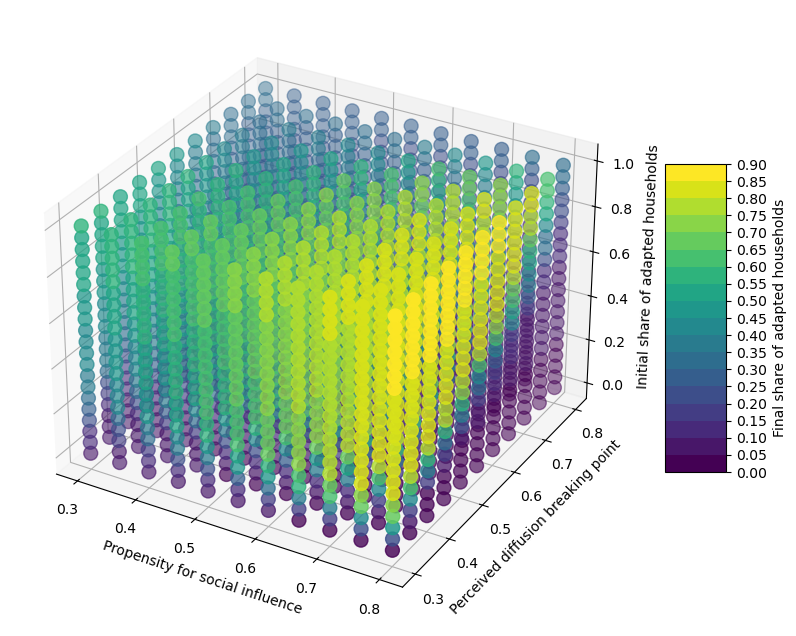

In [26]:
# making colorbar discrete
bounds = [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9]
cmap = plt.get_cmap('viridis', len(bounds)-1)
norm = BoundaryNorm(boundaries=bounds, ncolors=cmap.N)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(data_district_last_step_vis_grouped_['weight_SN_vs_PMT'], 
                data_district_last_step_vis_grouped_['per_HH_adapted_to_SN_prob_midpoint'], 
                data_district_last_step_vis_grouped_['set_hh_adapted_at_start'],
               c=data_district_last_step_vis_grouped_['fraction_adapted_any'], 
               cmap=cmap, norm = norm, 
               s=100)

cbar = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax, shrink=0.5, aspect=5, boundaries=bounds, ticks=bounds)
cbar.set_label('Final share of adapted households')

ax.set_xlabel('Propensity for social influence')
ax.set_ylabel('Perceived diffusion breaking point')
ax.set_zlabel('Initial share of adapted households')
plt.savefig('../reports/figures/scatter_3d_district.png', bbox_inches='tight', dpi=1000)
plt.show()

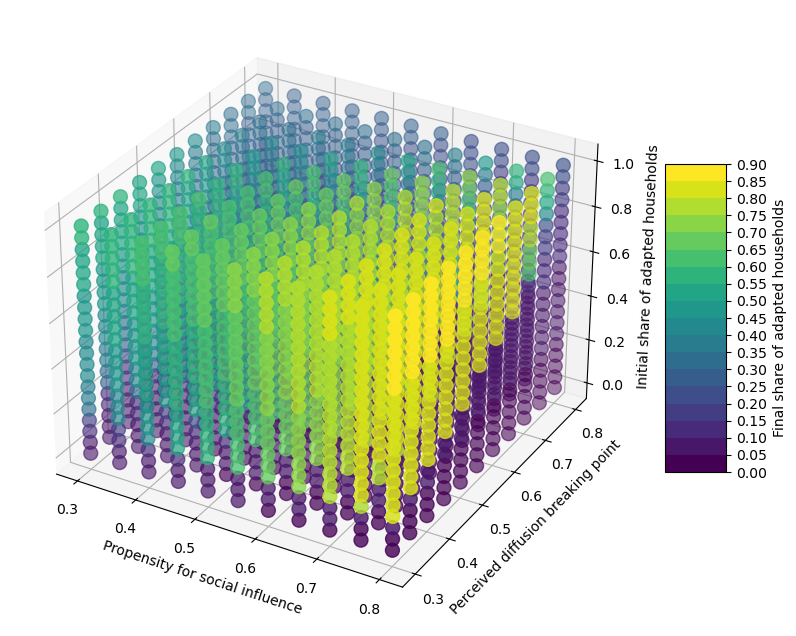

In [25]:
# making colorbar discrete
bounds = [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9]
cmap = plt.get_cmap('viridis', len(bounds)-1)
norm = BoundaryNorm(boundaries=bounds, ncolors=cmap.N)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(data_all_last_step_vis_grouped_['weight_SN_vs_PMT'], 
                data_all_last_step_vis_grouped_['per_HH_adapted_to_SN_prob_midpoint'], 
                data_all_last_step_vis_grouped_['set_hh_adapted_at_start'],
               c=data_all_last_step_vis_grouped_['fraction_adapted_any'], 
               cmap=cmap, norm = norm, 
               s=100)

cbar = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax, shrink=0.5, aspect=5, boundaries=bounds, ticks=bounds)
cbar.set_label('Final share of adapted households')

ax.set_xlabel('Propensity for social influence')
ax.set_ylabel('Perceived diffusion breaking point')
ax.set_zlabel('Initial share of adapted households')
plt.savefig('../reports/figures/scatter_3d_all.png', bbox_inches='tight', dpi=1000)
plt.show()

Thoughts:
- too few dots? 
- mean or max doesn't seem to matter that much for the visual
- 50% of runs with below 15% adaptation, 25% with 60 or more %, max 82% for adaptation of both

### Preparation for cuts in the Cube - planes

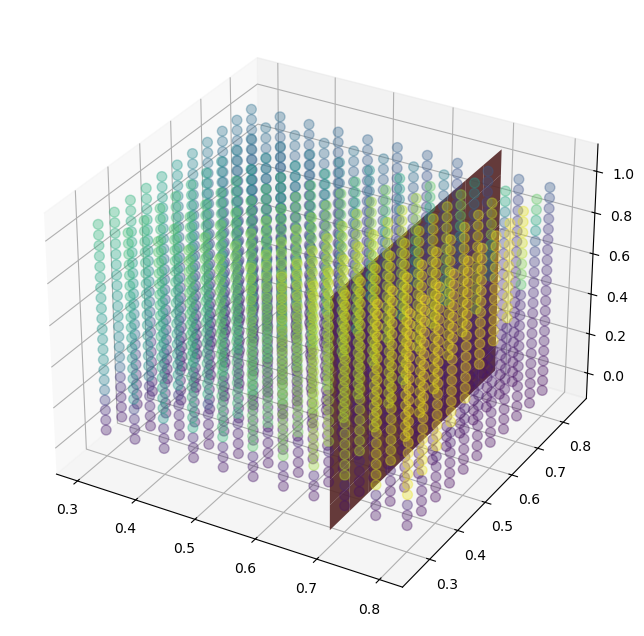

In [ ]:
# 3 D plot with planes
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(data_all_last_step_vis_grouped_['weight_SN_vs_PMT'], 
                data_all_last_step_vis_grouped_['per_HH_adapted_to_SN_prob_midpoint'], 
                data_all_last_step_vis_grouped_['set_hh_adapted_at_start'],
               c=data_all_last_step_vis_grouped_['fraction_adapted_any'], 
               alpha=0.35,
               cmap='viridis', s=50, vmin = 0, vmax =0.85)

# cbar = fig.colorbar(sc, ax=ax, shrink=0.5, aspect=5)
# cbar.set_label('HH adapted at end')

ax.set_xlabel(None)
ax.set_ylabel(None)
ax.set_zlabel(None)


# Add a plane at weight = 0.7
y = np.linspace(data_all_last_step_vis_grouped_['per_HH_adapted_to_SN_prob_midpoint'].min()-0.05, data_all_last_step_vis_grouped_['per_HH_adapted_to_SN_prob_midpoint'].max()+0.05, 10)
z = np.linspace(data_all_last_step_vis_grouped_['set_hh_adapted_at_start'].min()-0.05, data_all_last_step_vis_grouped_['set_hh_adapted_at_start'].max()+0.05, 10)
y, z = np.meshgrid(y, z)
x = np.full_like(y, 0.7)  # weight = 0.7

ax.plot_surface(x, y, z, alpha=0.9, color='indianred')

plt.savefig('../reports/figures/scatter_3d_plane_weight07.png', bbox_inches='tight', dpi=1000)
plt.show()

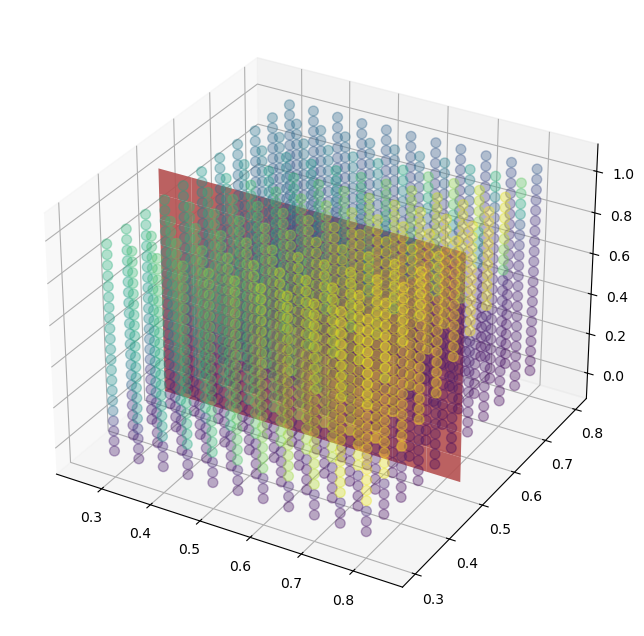

In [ ]:
# 3 D plot with planes
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(data_all_last_step_vis_grouped_['weight_SN_vs_PMT'], 
                data_all_last_step_vis_grouped_['per_HH_adapted_to_SN_prob_midpoint'], 
                data_all_last_step_vis_grouped_['set_hh_adapted_at_start'],
               c=data_all_last_step_vis_grouped_['fraction_adapted_any'], 
               alpha=0.35,
               cmap='viridis', s=50, vmin = 0, vmax =0.85)

# cbar = fig.colorbar(sc, ax=ax, shrink=0.5, aspect=5)
# cbar.set_label('HH adapted at end')

ax.set_xlabel(None)
ax.set_ylabel(None)
ax.set_zlabel(None)


# Add a plane at midpoint = 0.5
x = np.linspace(data_all_last_step_vis_grouped_['weight_SN_vs_PMT'].min()-0.05, data_all_last_step_vis_grouped_['weight_SN_vs_PMT'].max()+0.05, 10)
z = np.linspace(data_all_last_step_vis_grouped_['set_hh_adapted_at_start'].min()-0.05, data_all_last_step_vis_grouped_['set_hh_adapted_at_start'].max()+0.05, 10)
x, z = np.meshgrid(x, z)
y = np.full_like(x, 0.5)  # midpoint = 0.5

ax.plot_surface(x, y, z, alpha=0.9, color='indianred')

plt.savefig('../reports/figures/scatter_3d_plane_midpoint05.png', bbox_inches='tight', dpi=1000)
plt.show()

### Cuts in the 3D Cube

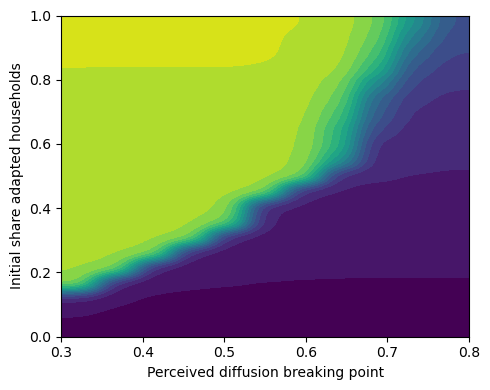

In [27]:
#  Filter the data
filtered_data = data_all_last_step_vis_grouped_[
    data_all_last_step_vis_grouped_['weight_SN_vs_PMT'] == 0.7
]

bounds = [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9]
cmap = plt.get_cmap('viridis', len(bounds)-1)
norm = BoundaryNorm(boundaries=bounds, ncolors=cmap.N)

# Pivot to grid
Z = filtered_data.pivot(
    index='set_hh_adapted_at_start',
    columns='per_HH_adapted_to_SN_prob_midpoint',
    values='fraction_adapted_any'
)

# Extract axes
x = Z.columns.values
y = Z.index.values
Z = Z.values

fig, ax = plt.subplots(figsize=(5, 4))

im = ax.imshow(
    Z,
    origin='lower',
    aspect='auto',
    extent=[x.min(), x.max(), y.min(), y.max()],
    cmap=cmap,
    norm=norm,
    interpolation='gaussian'   # <-- important
)


ax.set_xlabel('Perceived diffusion breaking point')
ax.set_ylabel('Initial share adapted households')

plt.tight_layout()
plt.savefig('../reports/figures/contour_2d_all_weight_07.png', bbox_inches='tight', dpi=1000)

plt.show()


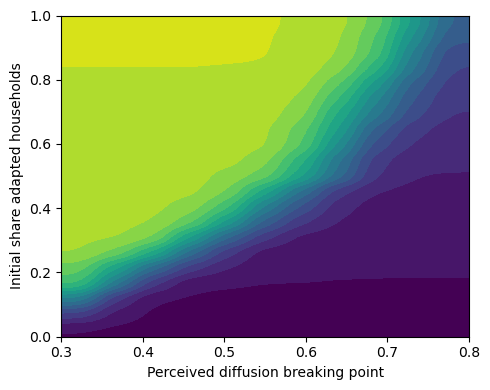

In [28]:
filtered_data = data_district_last_step_vis_grouped_[data_district_last_step_vis_grouped_['weight_SN_vs_PMT'] == 0.7]

bounds = [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9]
cmap = plt.get_cmap('viridis', len(bounds)-1)
norm = BoundaryNorm(boundaries=bounds, ncolors=cmap.N)

# Pivot to grid
Z = filtered_data.pivot(
    index='set_hh_adapted_at_start',
    columns='per_HH_adapted_to_SN_prob_midpoint',
    values='fraction_adapted_any'
)

# Extract axes
x = Z.columns.values
y = Z.index.values
Z = Z.values

fig, ax = plt.subplots(figsize=(5, 4))

im = ax.imshow(
    Z,
    origin='lower',
    aspect='auto',
    extent=[x.min(), x.max(), y.min(), y.max()],
    cmap=cmap,
    norm=norm,
    interpolation='gaussian'   # <-- important
)

ax.set_xlabel('Perceived diffusion breaking point')
ax.set_ylabel('Initial share adapted households')

plt.tight_layout()
plt.savefig('../reports/figures/contour_2d_district_weight_07.png', bbox_inches='tight', dpi=1000)

plt.show()


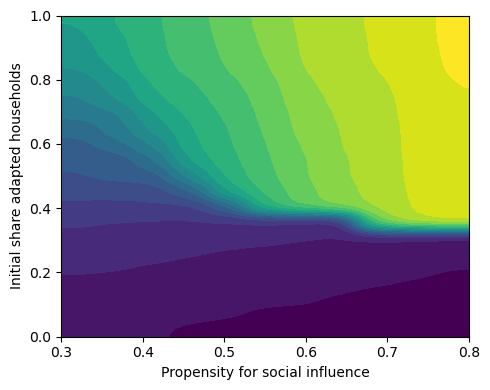

In [29]:
filtered_data = data_all_last_step_vis_grouped_[data_all_last_step_vis_grouped_['per_HH_adapted_to_SN_prob_midpoint'] == 0.5]

bounds = [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9]
cmap = plt.get_cmap('viridis', len(bounds)-1)
norm = BoundaryNorm(boundaries=bounds, ncolors=cmap.N)

# Pivot to grid
Z = filtered_data.pivot(
    index='set_hh_adapted_at_start',
    columns='weight_SN_vs_PMT',
    values='fraction_adapted_any'
)

# Extract axes
x = Z.columns.values
y = Z.index.values
Z = Z.values

fig, ax = plt.subplots(figsize=(5, 4))

im = ax.imshow(
    Z,
    origin='lower',
    aspect='auto',
    extent=[x.min(), x.max(), y.min(), y.max()],
    cmap=cmap,
    norm=norm,
    interpolation='gaussian'   # <-- important
)


ax.set_xlabel('Propensity for social influence')
ax.set_ylabel('Initial share adapted households')

plt.tight_layout()
plt.savefig('../reports/figures/contour_2d_all_midpoint_05.png', bbox_inches='tight', dpi=1000)
plt.show()


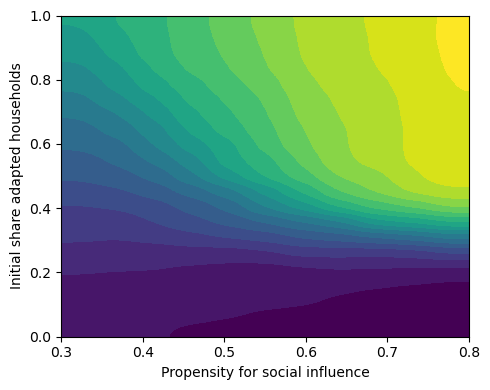

In [30]:
filtered_data = data_district_last_step_vis_grouped_[data_district_last_step_vis_grouped_['per_HH_adapted_to_SN_prob_midpoint'] == 0.5]

bounds = [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9]
cmap = plt.get_cmap('viridis', len(bounds)-1)
norm = BoundaryNorm(boundaries=bounds, ncolors=cmap.N)

# Pivot to grid
Z = filtered_data.pivot(
    index='set_hh_adapted_at_start',
    columns='weight_SN_vs_PMT',
    values='fraction_adapted_any'
)

# Extract axes
x = Z.columns.values
y = Z.index.values
Z = Z.values

fig, ax = plt.subplots(figsize=(5, 4))

im = ax.imshow(
    Z,
    origin='lower',
    aspect='auto',
    extent=[x.min(), x.max(), y.min(), y.max()],
    cmap=cmap,
    norm=norm,
    interpolation='gaussian'   # <-- important
)


ax.set_xlabel('Propensity for social influence')
ax.set_ylabel('Initial share adapted households')

plt.tight_layout()
plt.savefig('../reports/figures/contour_2d_district_midpoint_05.png', bbox_inches='tight', dpi=1000)

plt.show()


## Tipping requirements - different stable states?
Plots of initial vs final fraction of adapted with distributions

In [31]:
data_all[["per_HH_adapted_to_SN_prob_midpoint", "weight_SN_vs_PMT"]] = data_all[["per_HH_adapted_to_SN_prob_midpoint", "weight_SN_vs_PMT"]].apply(pd.to_numeric)
data_all = data_all.round({'per_HH_adapted_to_SN_prob_midpoint': 2, 'weight_SN_vs_PMT': 2})

In [32]:
print('midpoint values', data_all.per_HH_adapted_to_SN_prob_midpoint.unique())
print('weight values', data_all.weight_SN_vs_PMT.unique())

midpoint values [0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7  0.75 0.8 ]
weight values [0.3  0.65 0.75 0.35 0.5  0.4  0.8  0.55 0.6  0.45 0.7 ]


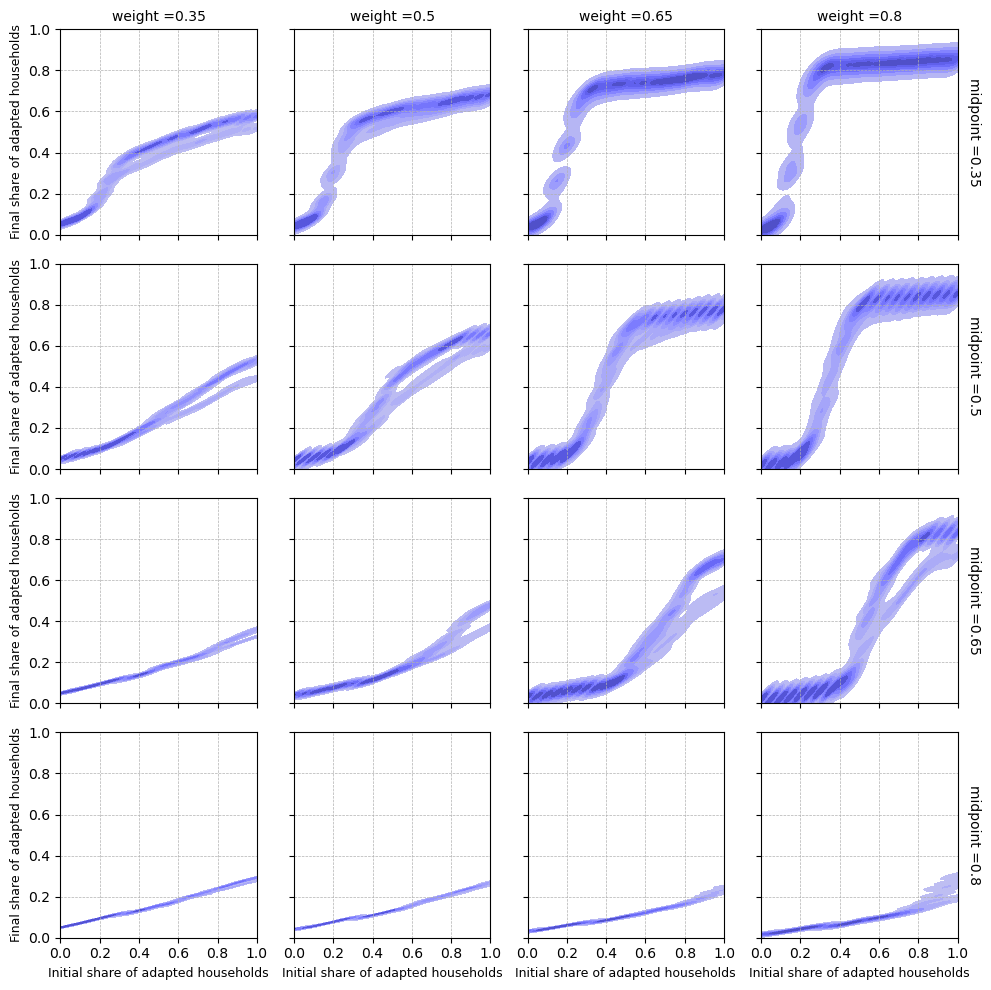

In [34]:

# Define the values for the grid
prob_values = [0.35, 0.50, 0.65, 0.80]
weight_values = [0.35, 0.50, 0.65, 0.80]

# Create subplots
fig, axes = plt.subplots(len(prob_values), len(weight_values), figsize=(10, 10), sharex=True, sharey=True)

for i, prob in enumerate(prob_values):
    for j, weight in enumerate(weight_values):
        ax = axes[i, j]
        x_data = data_district[(data_district.Step == 0) &
                               (data_district.per_HH_adapted_to_SN_prob_midpoint == prob) &
                               (data_district.weight_SN_vs_PMT == weight)].set_hh_adapted_at_start.to_numpy()
        y_data = data_district[(data_district.Step == 50) &
                               (data_district.per_HH_adapted_to_SN_prob_midpoint == prob) &
                               (data_district.weight_SN_vs_PMT == weight)].fraction_adapted_any.to_numpy()
        # sns.scatterplot(x=x_data, y=y_data, ax=ax, s = 5, color = 'black')
        sns.kdeplot(x=x_data, y=y_data, ax=ax, color = 'blue', zorder=0, levels=7, fill=True, bw_adjust=.4)

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        
        ax.set_xticks(np.arange(0, 1.1, 0.2))
        ax.set_yticks(np.arange(0, 1.1, 0.2))
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)
        # ax.set_title(f"prob={prob}, weight={weight}")
        
        if i == 0:
            ax.set_title(f"weight ={weight}", fontsize = 10)
        
        if i == len(prob_values) - 1:
            ax.set_xlabel("Initial share of adapted households", fontsize = 9)

        if j == 0:
            ax.set_ylabel("Final share of adapted households", fontsize = 9)
        
        if j == len(weight_values) - 1:
            ax.annotate(f"midpoint ={prob}", xy=(1.05, 0.5), xycoords='axes fraction',
                        ha='left', va='center', fontsize=10, rotation=270)

plt.tight_layout()
plt.savefig('../reports/figures/scatter_init_end_fraction_adapted_district.png', bbox_inches='tight', dpi=1000)


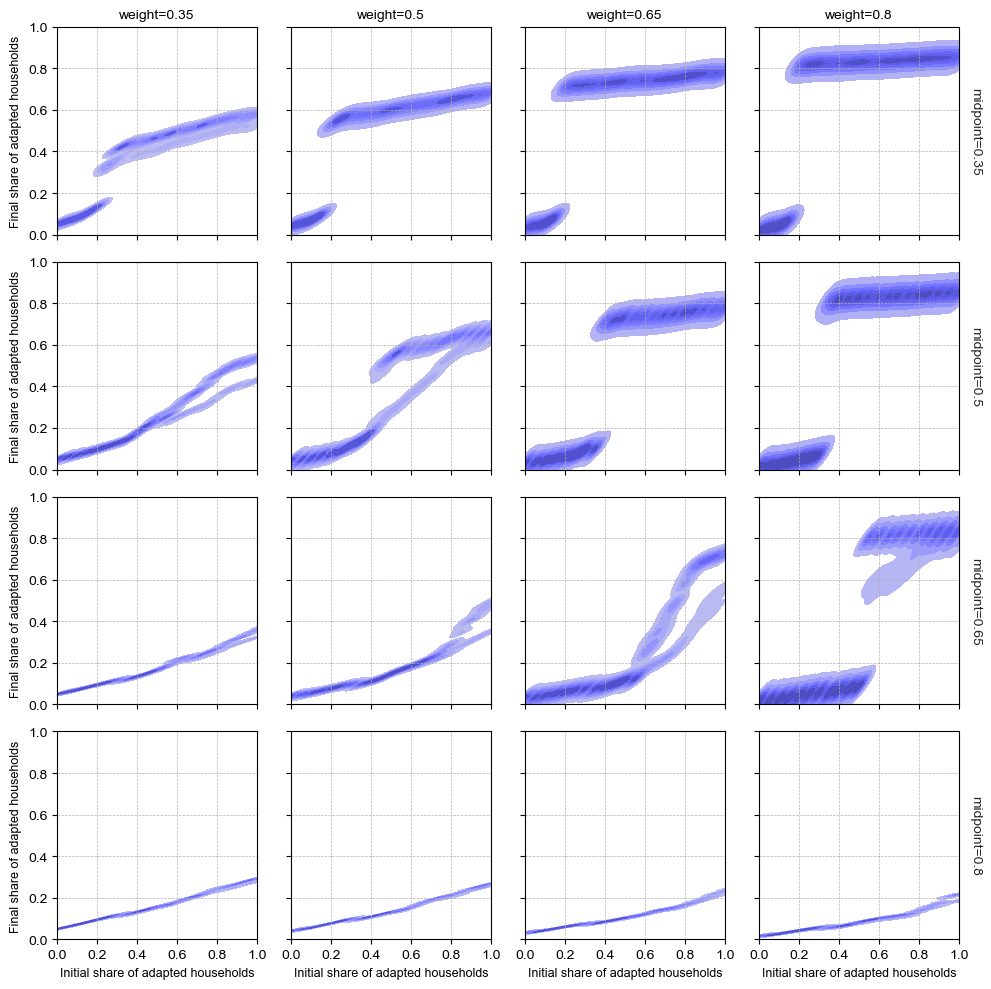

In [35]:

# Define the values for the grid
prob_values = [0.35, 0.50, 0.65, 0.80]
weight_values = [0.35, 0.50, 0.65, 0.80]

# Create subplots
fig, axes = plt.subplots(len(prob_values), len(weight_values), figsize=(10, 10), sharex=True, sharey=True)

for i, prob in enumerate(prob_values):
    for j, weight in enumerate(weight_values):
        ax = axes[i, j]
        sns.set_style("whitegrid")
        x_data = data_all[(data_all.Step == 0) &
                               (data_all.per_HH_adapted_to_SN_prob_midpoint == prob) &
                               (data_all.weight_SN_vs_PMT == weight)].set_hh_adapted_at_start.to_numpy()
        y_data = data_all[(data_all.Step == 50) &
                               (data_all.per_HH_adapted_to_SN_prob_midpoint == prob) &
                               (data_all.weight_SN_vs_PMT == weight)].fraction_adapted_any.to_numpy()
        # sns.scatterplot(x=x_data, y=y_data, ax=ax, s = 5, color = 'black')
        sns.kdeplot(x=x_data, y=y_data, ax=ax, 
                    color = 'blue', bw_adjust=.4,
                    zorder=0, levels=7, 
                    fill=True)

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

        ax.set_xticks(np.arange(0, 1.1, 0.2))
        ax.set_yticks(np.arange(0, 1.1, 0.2))
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)
        # ax.set_title(f"prob={prob}, weight={weight}")
        
        if i == 0:
            ax.set_title(f"weight={weight}", fontsize = 10)
        
        if i == len(prob_values) - 1:
            ax.set_xlabel("Initial share of adapted households", fontsize = 9)

        if j == 0:
            ax.set_ylabel("Final share of adapted households", fontsize = 9)
        
        if j == len(weight_values) - 1:
            ax.annotate(f"midpoint={prob}", xy=(1.05, 0.5), xycoords='axes fraction',
                        ha='left', va='center', fontsize=10, rotation=270)


plt.tight_layout()
plt.savefig('../reports/figures/scatter_init_end_fraction_adapted_all.png', bbox_inches='tight', dpi=1000)


#### Within District Tipping

In [36]:
data_district_tipping = data_district_tipping[['Step', 'set_hh_adapted_at_start', 'per_HH_adapted_to_SN_prob_midpoint', 'weight_SN_vs_PMT',
    'adapted_wp_11', 'adapted_dp_11', 'adapted_wp_21', 'adapted_dp_21', 'adapted_wp_12', 'adapted_dp_12', 'adapted_any_11', 'adapted_any_21', 'adapted_any_12']]

In [37]:
data_district_tipping[["per_HH_adapted_to_SN_prob_midpoint", "weight_SN_vs_PMT"]] = data_district_tipping[["per_HH_adapted_to_SN_prob_midpoint", "weight_SN_vs_PMT"]].apply(pd.to_numeric)
data_district_tipping = data_district_tipping.round({'per_HH_adapted_to_SN_prob_midpoint': 2, 'weight_SN_vs_PMT': 2})


In [38]:
data_district_tipping_start = data_district_tipping[data_district_tipping.Step == 0]
data_district_tipping_start.describe()

,Step,set_hh_adapted_at_start,per_HH_adapted_to_SN_prob_midpoint,weight_SN_vs_PMT,adapted_wp_11,adapted_dp_11,adapted_wp_21,adapted_dp_21,adapted_wp_12,adapted_dp_12,adapted_any_11,adapted_any_21,adapted_any_12
count,127050.0,127050.000000,127050.000000,127050.000000,127050.000000,127050.000000,127050.000000,127050.000000,127050.000000,127050.000000,127050.000000,127050.000000,127050.000000
mean,0.0,0.500000,0.550000,0.550000,26.106580,25.903471,28.780079,29.922936,28.212216,30.201747,27.312956,31.674420,31.225864
std,0.0,0.302766,0.158115,0.158115,15.358975,15.636915,14.825841,16.664667,14.186828,15.383697,16.486117,16.338789,15.535774
min,0.0,0.000000,0.300000,0.300000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,0.0,0.250000,0.400000,0.400000,10.000000,10.000000,16.000000,15.000000,16.000000,17.000000,10.000000,17.000000,18.000000
50%,0.0,0.500000,0.550000,0.550000,30.000000,29.000000,33.000000,34.000000,33.000000,35.000000,30.000000,36.000000,36.000000
75%,0.0,0.750000,0.700000,0.700000,40.000000,41.000000,43.000000,46.000000,41.000000,44.000000,43.000000,47.000000,45.000000
max,0.0,1.000000,0.800000,0.800000,48.000000,49.000000,47.000000,49.000000,46.000000,50.000000,50.000000,50.000000,50.000000


In [39]:
data_district_tipping['fraction_any_11'] = data_district_tipping['adapted_any_11']/50
data_district_tipping['fraction_any_21'] = data_district_tipping['adapted_any_21']/50
data_district_tipping['fraction_any_12'] = data_district_tipping['adapted_any_12']/50

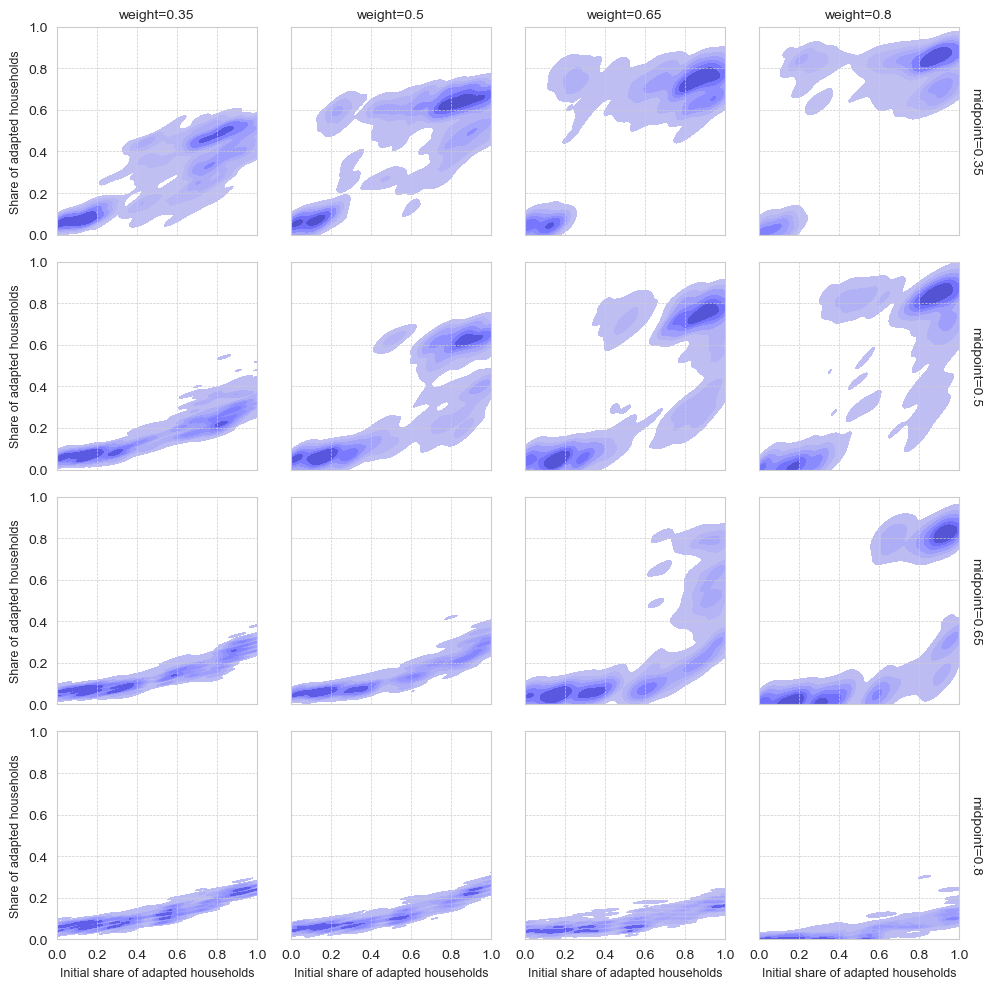

In [40]:
# Define the values for the grid
prob_values = [0.35, 0.50, 0.65, 0.80]
weight_values = [0.35, 0.50, 0.65, 0.80]

# Create subplots
fig, axes = plt.subplots(len(prob_values), len(weight_values), figsize=(10, 10), sharex=True, sharey=True)

for i, prob in enumerate(prob_values):
    for j, weight in enumerate(weight_values):
        ax = axes[i, j]
        x_data = data_district_tipping[(data_district_tipping.Step == 0) &
                               (data_district_tipping.per_HH_adapted_to_SN_prob_midpoint == prob) &
                               (data_district_tipping.weight_SN_vs_PMT == weight)].fraction_any_11.to_numpy()
        y_data = data_district_tipping[(data_district_tipping.Step == 50) &
                               (data_district_tipping.per_HH_adapted_to_SN_prob_midpoint == prob) &
                               (data_district_tipping.weight_SN_vs_PMT == weight)].fraction_any_11.to_numpy()
        # sns.scatterplot(x=x_data, y=y_data, ax=ax, s = 5, color = 'black')
        sns.kdeplot(x=x_data, y=y_data, ax=ax, color = 'blue', zorder=0, levels=7, fill=True, bw_adjust=.4)

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        
        ax.set_xticks(np.arange(0, 1.1, 0.2))
        ax.set_yticks(np.arange(0, 1.1, 0.2))
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)
        # ax.set_title(f"prob={prob}, weight={weight}")
        
        if i == 0:
            ax.set_title(f"weight={weight}", fontsize = 10)
        
        if i == len(prob_values) - 1:
            ax.set_xlabel("Initial share of adapted households", fontsize = 9)

        if j == 0:
            ax.set_ylabel("Share of adapted households", fontsize = 9)
        
        if j == len(weight_values) - 1:
            ax.annotate(f"midpoint={prob}", xy=(1.05, 0.5), xycoords='axes fraction',
                        ha='left', va='center', fontsize=10, rotation=270)


plt.tight_layout()
plt.savefig('../reports/figures/tipping_figure_district_11.png', bbox_inches='tight', dpi=1000)


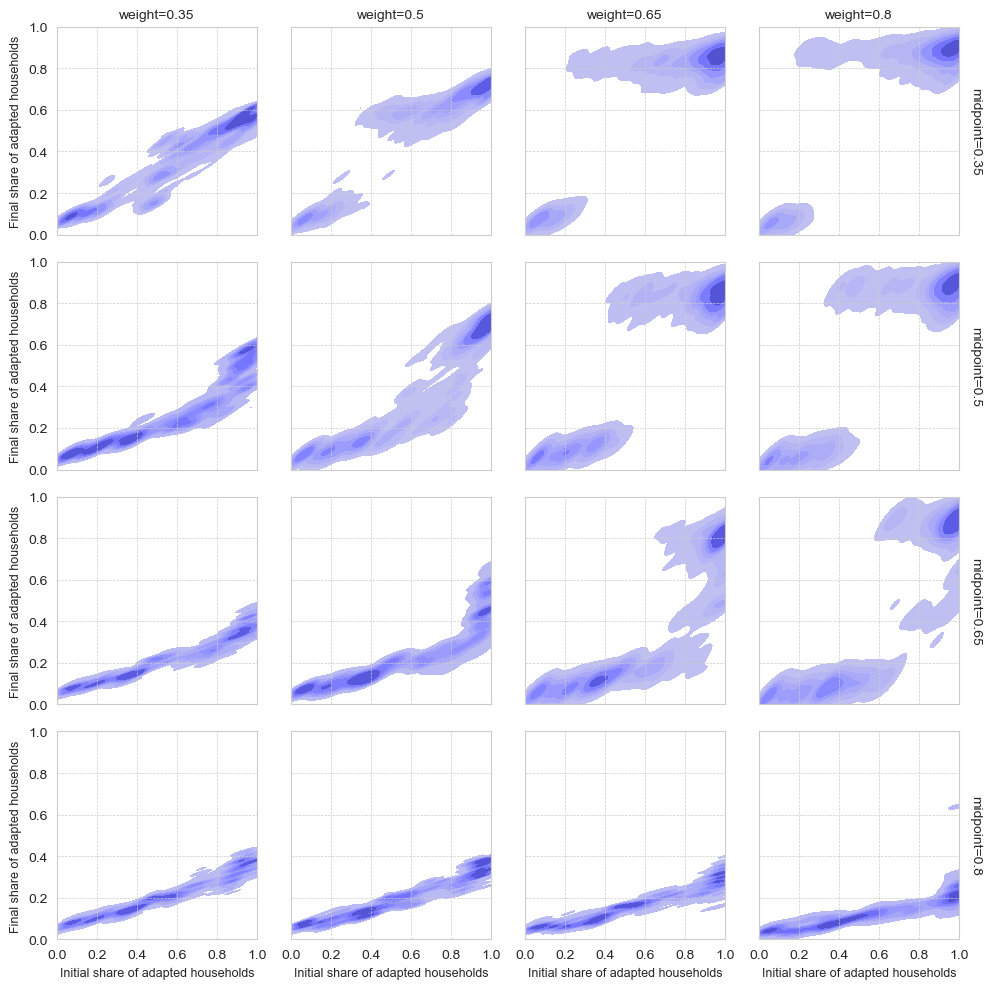

In [41]:
# Define the values for the grid
prob_values = [0.35, 0.50, 0.65, 0.80]
weight_values = [0.35, 0.50, 0.65, 0.80]

# Create subplots
fig, axes = plt.subplots(len(prob_values), len(weight_values), figsize=(10, 10), sharex=True, sharey=True)

for i, prob in enumerate(prob_values):
    for j, weight in enumerate(weight_values):
        ax = axes[i, j]
        x_data = data_district_tipping[(data_district_tipping.Step == 0) &
                               (data_district_tipping.per_HH_adapted_to_SN_prob_midpoint == prob) &
                               (data_district_tipping.weight_SN_vs_PMT == weight)].fraction_any_21.to_numpy()
        y_data = data_district_tipping[(data_district_tipping.Step == 50) &
                               (data_district_tipping.per_HH_adapted_to_SN_prob_midpoint == prob) &
                               (data_district_tipping.weight_SN_vs_PMT == weight)].fraction_any_21.to_numpy()
        # sns.scatterplot(x=x_data, y=y_data, ax=ax, s = 5, color = 'black')
        sns.kdeplot(x=x_data, y=y_data, ax=ax, color = 'blue', zorder=0, levels=7, fill=True, bw_adjust=.4)

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        
        ax.set_xticks(np.arange(0, 1.1, 0.2))
        ax.set_yticks(np.arange(0, 1.1, 0.2))
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)
        # ax.set_title(f"prob={prob}, weight={weight}")
        
        if i == 0:
            ax.set_title(f"weight={weight}", fontsize = 10)
        
        if i == len(prob_values) - 1:
            ax.set_xlabel("Initial share of adapted households", fontsize = 9)

        if j == 0:
            ax.set_ylabel("Final share of adapted households", fontsize = 9)
        
        if j == len(weight_values) - 1:
            ax.annotate(f"midpoint={prob}", xy=(1.05, 0.5), xycoords='axes fraction',
                        ha='left', va='center', fontsize=10, rotation=270)


plt.tight_layout()
plt.savefig('../reports/figures/tipping_figure_district_21.png', bbox_inches='tight', dpi=1000)

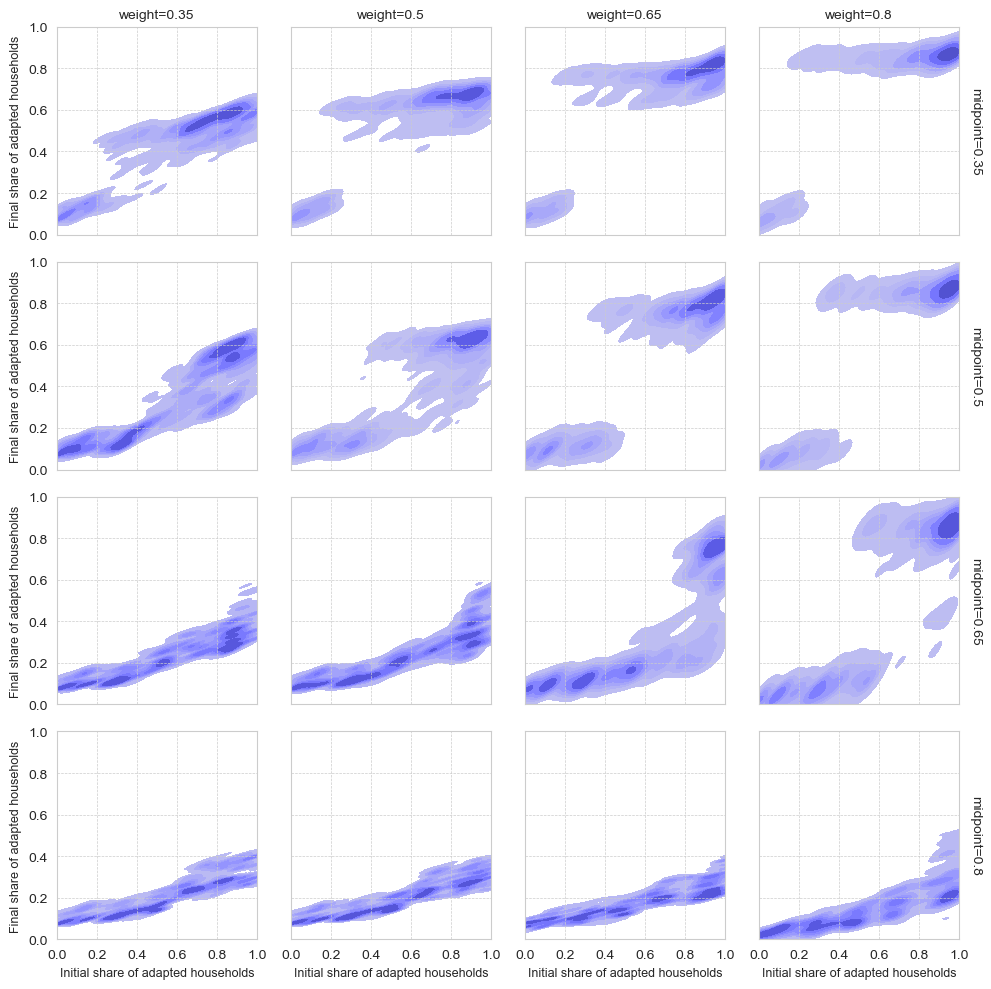

In [42]:
# Define the values for the grid
prob_values = [0.35, 0.50, 0.65, 0.80]
weight_values = [0.35, 0.50, 0.65, 0.80]

# Create subplots
fig, axes = plt.subplots(len(prob_values), len(weight_values), figsize=(10, 10), sharex=True, sharey=True)

for i, prob in enumerate(prob_values):
    for j, weight in enumerate(weight_values):
        ax = axes[i, j]
        x_data = data_district_tipping[(data_district_tipping.Step == 0) &
                               (data_district_tipping.per_HH_adapted_to_SN_prob_midpoint == prob) &
                               (data_district_tipping.weight_SN_vs_PMT == weight)].fraction_any_12.to_numpy()
        y_data = data_district_tipping[(data_district_tipping.Step == 50) &
                               (data_district_tipping.per_HH_adapted_to_SN_prob_midpoint == prob) &
                               (data_district_tipping.weight_SN_vs_PMT == weight)].fraction_any_12.to_numpy()
        # sns.scatterplot(x=x_data, y=y_data, ax=ax, s = 5, color = 'black')
        sns.kdeplot(x=x_data, y=y_data, ax=ax, color = 'blue', zorder=0, levels=7, fill=True, bw_adjust=.4)

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        
        ax.set_xticks(np.arange(0, 1.1, 0.2))
        ax.set_yticks(np.arange(0, 1.1, 0.2))
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)
        # ax.set_title(f"prob={prob}, weight={weight}")
        
        if i == 0:
            ax.set_title(f"weight={weight}", fontsize = 10)
        
        if i == len(prob_values) - 1:
            ax.set_xlabel("Initial share of adapted households", fontsize = 9)

        if j == 0:
            ax.set_ylabel("Final share of adapted households", fontsize = 9)
        
        if j == len(weight_values) - 1:
            ax.annotate(f"midpoint={prob}", xy=(1.05, 0.5), xycoords='axes fraction',
                        ha='left', va='center', fontsize=10, rotation=270)


plt.tight_layout()
plt.savefig('../reports/figures/tipping_figure_district_12.png', bbox_inches='tight', dpi=1000)


### Combining distric level SN calcualtion with within district tipping figure

In [44]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

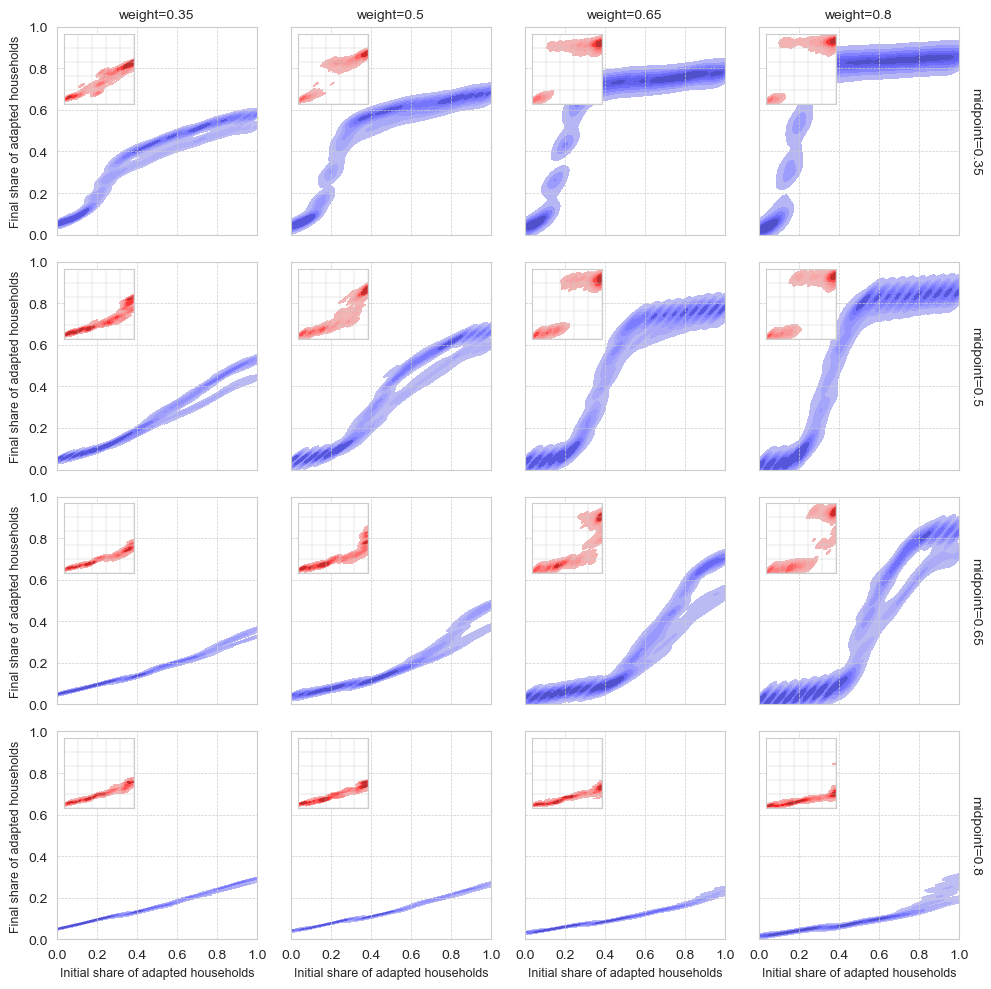

In [45]:
# Option 2: mini-plot within bigger plot
# Define the values for the grid
prob_values = [0.35, 0.50, 0.65, 0.80]
weight_values = [0.35, 0.50, 0.65, 0.80]

# Create subplots
fig, axes = plt.subplots(len(prob_values), len(weight_values), figsize=(10, 10), sharex=True, sharey=True)

for i, prob in enumerate(prob_values):
    for j, weight in enumerate(weight_values):
        ax = axes[i, j]
        sns.set_style("whitegrid")
        

        
        # add second kde plot for district tipping data here
        inset_ax = inset_axes(ax, width=.7, height=.7, loc="upper left")
        x_data_district = data_district_tipping[(data_district_tipping.Step == 0) &
                               (data_district_tipping.per_HH_adapted_to_SN_prob_midpoint == prob) &
                               (data_district_tipping.weight_SN_vs_PMT == weight)].fraction_any_21.to_numpy()
        y_data_district = data_district_tipping[(data_district_tipping.Step == 50) &
                               (data_district_tipping.per_HH_adapted_to_SN_prob_midpoint == prob) &
                               (data_district_tipping.weight_SN_vs_PMT == weight)].fraction_any_21.to_numpy()
        # sns.scatterplot(x=x_data, y=y_data, ax=ax, s = 5, color = 'black')
        sns.kdeplot(x=x_data_district, y=y_data_district, ax=inset_ax, 
                    color = 'darkred', bw_adjust=.4,
                    zorder=0, levels=7, 
                    fill=True)
        
        inset_ax.set_xlim(0, 1)
        inset_ax.set_ylim(0, 1)
        inset_ax.set_xticks(np.arange(0, 1.1, 0.2))
        inset_ax.set_yticks(np.arange(0, 1.1, 0.2))
        inset_ax.xaxis.set_ticklabels([])
        inset_ax.yaxis.set_ticklabels([])
        inset_ax.grid(True, which='both', linestyle='-', linewidth=0.3)

        x_data = data_district[(data_district.Step == 0) &
                               (data_district.per_HH_adapted_to_SN_prob_midpoint == prob) &
                               (data_district.weight_SN_vs_PMT == weight)].set_hh_adapted_at_start.to_numpy()
        y_data = data_district[(data_district.Step == 50) &
                               (data_district.per_HH_adapted_to_SN_prob_midpoint == prob) &
                               (data_district.weight_SN_vs_PMT == weight)].fraction_adapted_any.to_numpy()
        # sns.scatterplot(x=x_data, y=y_data, ax=ax, s = 5, color = 'black')
        sns.kdeplot(x=x_data, y=y_data, ax=ax, 
                    color = 'blue', bw_adjust=.4,
                    zorder=0, levels=7, 
                    fill=True)

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

        ax.set_xticks(np.arange(0, 1.1, 0.2))
        ax.set_yticks(np.arange(0, 1.1, 0.2))
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)
        # ax.set_title(f"prob={prob}, weight={weight}")
        
        if i == 0:
            ax.set_title(f"weight={weight}", fontsize = 10)
        
        if i == len(prob_values) - 1:
            ax.set_xlabel("Initial share of adapted households", fontsize = 9)

        if j == 0:
            ax.set_ylabel("Final share of adapted households", fontsize = 9)
        
        if j == len(weight_values) - 1:
            ax.annotate(f"midpoint={prob}", xy=(1.05, 0.5), xycoords='axes fraction',
                        ha='left', va='center', fontsize=10, rotation=270)


plt.tight_layout()
plt.savefig('../reports/figures/scatter_init_end_fraction_adapted_district_with_district_tipping.png', bbox_inches='tight', dpi=1000)

## Empirical - where are we at right now?


In [46]:
data_empirical_end = data_empirical[data_empirical['Step'] == 50]

In [47]:
data_empirical_end.describe()

,Step,seed,nr_households,prop_inc_for_damage_adaptation,weight_opinion_others,threshold_similarity_bias,proportion_ties_added_per_step,proportion_ties_removed_per_step,fraction_ties_added_at_flood,flood_remembrance_period,consider_measure_every_x_steps,minimum_intention_to_consider_measure,worry_increase_with_flood,min_worry_after_flood,transformative_threshold,collect_agent_data,edges,avg_clustering,density_nw,cumulative_damage,cumulative_damage_no_adaptation,fraction_wet_proofed,fraction_dry_proofed,fraction_adapted_any,fraction_adapted_both,nr_HH_severely_affected,nr_HH_severely_affected_adapted_any,transformative_adaptation,avg_intention_SN,avg_intention_PMT_DP,avg_intention_PMT_WP,avg_intention_overall_DP,avg_intention_overall_WP
count,50.0,50.00000,50.0,5.000000e+01,50.0,5.000000e+01,50.0,50.0,50.0,50.0,50.0,50.0,5.000000e+01,5.000000e+01,5.000000e+01,50.0,50.0,5.000000e+01,5.000000e+01,5.000000e+01,5.000000e+01,50.000000,50.000000,50.000000,50.000000,50.0,50.000000,50.0,50.000000,50.000000,50.000000,50.000000,50.000000
mean,50.0,12369.50000,1000.0,5.000000e-02,0.5,2.000000e-01,0.0,0.0,0.0,5.0,1.0,0.0,3.000000e-01,1.000000e-01,7.000000e-01,0.0,393.0,7.720000e-03,7.900000e-04,2.208666e+07,2.254535e+07,0.051800,0.050780,0.053320,0.049260,250.0,13.260000,0.0,0.003566,0.055450,0.101862,0.031270,0.054374
std,0.0,14.57738,0.0,2.102802e-17,0.0,8.411210e-17,0.0,0.0,0.0,0.0,0.0,0.0,2.803737e-16,4.205605e-17,1.121495e-16,0.0,0.0,3.504671e-18,4.380838e-19,1.327695e+07,1.353843e+07,0.003064,0.002888,0.002903,0.003043,0.0,1.860546,0.0,0.000194,0.002367,0.000723,0.001192,0.000426
min,50.0,12345.00000,1000.0,5.000000e-02,0.5,2.000000e-01,0.0,0.0,0.0,5.0,1.0,0.0,3.000000e-01,1.000000e-01,7.000000e-01,0.0,393.0,7.720000e-03,7.900000e-04,6.189932e+06,6.319477e+06,0.043000,0.043000,0.046000,0.040000,250.0,10.000000,0.0,0.003100,0.049500,0.100000,0.028200,0.053200
25%,50.0,12357.25000,1000.0,5.000000e-02,0.5,2.000000e-01,0.0,0.0,0.0,5.0,1.0,0.0,3.000000e-01,1.000000e-01,7.000000e-01,0.0,393.0,7.720000e-03,7.900000e-04,1.319929e+07,1.347460e+07,0.050000,0.049250,0.052000,0.047250,250.0,12.000000,0.0,0.003500,0.054525,0.101425,0.030725,0.054125
50%,50.0,12369.50000,1000.0,5.000000e-02,0.5,2.000000e-01,0.0,0.0,0.0,5.0,1.0,0.0,3.000000e-01,1.000000e-01,7.000000e-01,0.0,393.0,7.720000e-03,7.900000e-04,1.640130e+07,1.674565e+07,0.052500,0.051500,0.054000,0.050000,250.0,13.000000,0.0,0.003600,0.056100,0.101900,0.031350,0.054350
75%,50.0,12381.75000,1000.0,5.000000e-02,0.5,2.000000e-01,0.0,0.0,0.0,5.0,1.0,0.0,3.000000e-01,1.000000e-01,7.000000e-01,0.0,393.0,7.720000e-03,7.900000e-04,4.231624e+07,4.316871e+07,0.054000,0.052750,0.055000,0.051000,250.0,14.000000,0.0,0.003700,0.057075,0.102375,0.031875,0.054600
max,50.0,12394.00000,1000.0,5.000000e-02,0.5,2.000000e-01,0.0,0.0,0.0,5.0,1.0,0.0,3.000000e-01,1.000000e-01,7.000000e-01,0.0,393.0,7.720000e-03,7.900000e-04,4.359934e+07,4.455730e+07,0.057000,0.055000,0.058000,0.054000,250.0,18.000000,0.0,0.003900,0.058700,0.103200,0.033300,0.055300


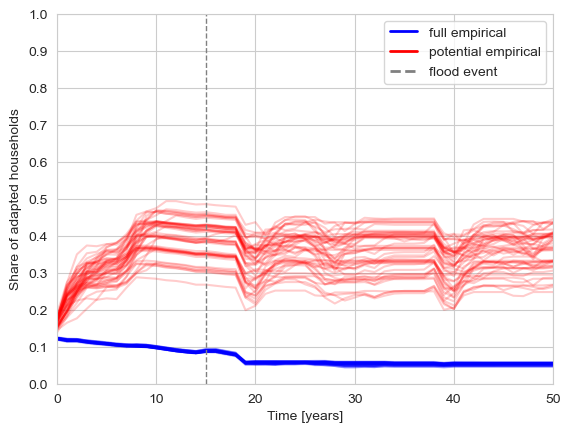

In [49]:
for seed_id, group in data_empirical.groupby('seed'):
    plt.plot(group['Step'], group['fraction_adapted_any'], alpha=0.2, color = 'blue')

for seed_id, group in data_empirical_pot.groupby('seed'):
    plt.plot(group['Step'], group['fraction_adapted_any'], alpha=0.2, color = 'red')

custom_lines = [Line2D([0], [0], color='blue', lw=2),
                Line2D([0], [0], color='red', lw=2),
                Line2D([0], [0], color='gray', ls = '--', lw=2)]

plt.axvline(15, color='gray', ls = '--', lw = 1) # vertical
plt.xlim(0, 50)
plt.ylim(0, 0.3)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.grid(True)
plt.xlabel('Time [years]')
plt.ylabel('Share of adapted households')
plt.legend(custom_lines, ['full empirical', 'potential empirical', 'flood event'])
plt.savefig('../reports/figures/line_empirical_potential.png', bbox_inches='tight', dpi=1000)
plt.show()
